<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fjhamilton/weeks/week_07/07_Wing_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 07: Building the diffusion forward pass

Up to now you have built a fully analytic generative model: given a cycle's
amplitude, the **classical statistical model** from Weeks 03–06 emits a
per-year Gaussian over absolute emergence latitude, and you sample from it
directly. The model is interpretable and physically motivated, but it is also
a strong assumption — a single Gaussian per year, with shape parameters that
depend linearly on amplitude. Looking at the empirical distributions, you have
already seen places where the Gaussian fit leaves structure on the table:
bimodality at certain phases of certain cycles, asymmetric tails, year-to-year
fluctuations that a smooth analytic model cannot reproduce.

The goal of the next three weeks is to model what the classical model leaves
behind. For each 6-month window of each hemispheric cycle we will compute the
**residual** — the difference between the empirical latitude histogram and the
parametric histogram — and train a **score-based diffusion model** to generate
plausible residuals. The full generative model becomes *classical statistical
model + sampled residual*. If the diffusion model has learned anything
systematic, the combined model should outperform the classical model alone on
the scoreboard NLL.

**Strategic split across the three weeks.** A diffusion model has two parts:
a **forward process** that progressively corrupts data into noise (purely
numerical — no learning involved), and a **reverse process** that
progressively undoes the corruption (the learned part — a neural network).
All the diffusion-specific mathematics lives in the forward process; the
reverse process is a standard regression problem dressed in PyTorch. We
exploit this separation deliberately:

- **Week 07 (this notebook):** Build the dataset of residuals and implement
  the forward process in pure numpy. By the end of this week you will be able
  to take a real residual and watch it dissolve into Gaussian noise across
  T timesteps, with every line of code transparent and debuggable.
- **Week 08:** Build the AI/ML pipeline (PyTorch + Lightning) and train an
  **unconditional** diffusion model that learns the marginal distribution of
  residuals. Sample from it and verify that the samples match the training
  distribution.
- **Week 09:** Add **conditioning** on (cycle amplitude, universal-path
  latitude). Sample residuals for held-out test cycles, combine with the
  classical model, and run the result through `compute_global_nll`.

By the end of Week 09 you will have a working **conditional generative model**
for the butterfly diagram that learns from data what the classical model
misses. This week is the foundation: get the forward process exactly right,
and the rest is standard deep learning.

**By the end of this notebook you should be able to:**
- Explain what a **residual** is in vector form, and why each one is a single
  point in a 15-dimensional space (not a function of latitude).
- Construct a **stratified** training / validation / test split by
  hemispheric cycle amplitude, and explain why all three splits are needed
  for diffusion training.
- Implement and visualize a **cosine noise schedule** with T = 200 timesteps,
  and read off α_t, σ_t, and the **signal-to-noise ratio** SNR(t) at any
  point on the schedule.
- Apply the **forward corruption** r_t = α_t · r + σ_t · ε to map any clean
  residual to any noise level in a single step.
- Verify empirically that at t = T the corrupted residuals are
  indistinguishable from N(0, I), regardless of the original residual — this
  is the property that lets the reverse process start from pure noise next
  week.


In [3]:
import os, subprocess, sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
# repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()

  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 1) Load data

We work with the same composite catalog of daily sunspot group measurements used in Weeks 03 and 04. Each row records one sunspot group observation: its date, heliographic latitude, and corrected area in millionths of a solar hemisphere (MSH). We add convenience columns for hemisphere, absolute latitude, and decimal year that all subsequent sections depend on.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit, minimize_scalar, minimize

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_peak_area.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)
df = df[df["latitude"].notna()].copy()

df["hemisphere"]   = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
df["abs_latitude"] = df["latitude"].abs()
df["year"] = df["date"].dt.year
df["decimal_year"] = df["date"].dt.year + df["date"].dt.dayofyear / 365.25

# Remove pores and small objects
df = df[df["correctedArea"] > 30].copy()


df.head()

/tmp/ipykernel_1567/2077808080.py:11: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_1567/2077808080.py:11: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,hour,minute,second,latitude,longitude,correctedArea,CAUnc,uniqueID,CYCLE,survey,time,hemisphere,abs_latitude,year,decimal_year
0,1825-11-05,12.0,30.0,0.0,-1.2,331.8,2120.0,570.0,SC_101,NaN,1.0,1825.843258,south,1.2,1825,1825.845996
3,1825-11-08,12.0,0.0,0.0,-17.9,321.8,670.0,190.0,SC_102,NaN,1.0,1825.851472,south,17.9,1825,1825.854209
4,1825-11-10,12.0,0.0,0.0,-27.4,318.1,520.0,150.0,SC_103,NaN,1.0,1825.856947,south,27.4,1825,1825.859685
7,1825-11-14,12.0,0.0,0.0,-12.4,324.5,630.0,180.0,SC_104,NaN,1.0,1825.867899,south,12.4,1825,1825.870637
9,1825-11-16,10.0,30.0,0.0,14.9,324.5,380.0,120.0,SC_105,NaN,1.0,1825.873374,north,14.9,1825,1825.876112


/tmp/ipykernel_1567/2945696721.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


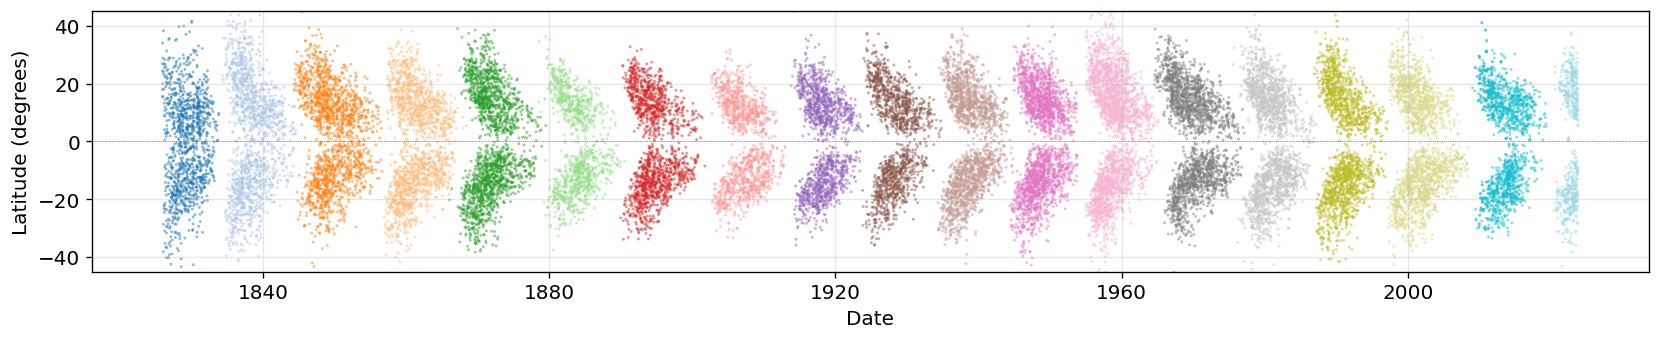

In [5]:
# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=3,
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}",
               alpha=0.5, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 2) Standardize time: align cycles at the 15° crossing (τ)

Solar cycles don't start on the same calendar date and don't last the same length of time, so we can't compare them on a shared time axis without first choosing a common reference point. The anchor we use is the moment when the **yearly mean absolute emergence latitude crosses 15° on its way equatorward** — a latitude that falls reliably in the well-observed middle of every cycle.

For each (cycle, hemisphere) pair we find that crossing by linear interpolation between the last year the mean sits above 15° and the first year it falls below. The shifted coordinate **τ = decimal\_year − t₀** is in physical units (years) and places all cycles on the same footing regardless of when they actually occurred.

In [6]:
t0_lookup = {}
for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    yearly_mean = group.groupby("year")["abs_latitude"].mean().sort_index()
    years, means = yearly_mean.index.values, yearly_mean.values
    below = means < 15.0
    if not below.any() or below.all():
        continue
    idx1 = np.argmax(below)
    if idx1 == 0:
        continue
    y0, mu0 = years[idx1 - 1], means[idx1 - 1]
    y1, mu1 = years[idx1],     means[idx1]
    t0_lookup[(cyc, hemi)] = y0 + (15.0 - mu0) / (mu1 - mu0)

df["t0"]  = df.apply(lambda r: t0_lookup.get((r["CYCLE"], r["hemisphere"]), np.nan), axis=1)
df["tau"] = df["decimal_year"] - df["t0"]

## 3) Fit a universal mean path μ(τ) and refine the time origin

The equatorward drift of the mean emergence latitude follows an exponential decay:

$$\mu(\tau) = a \, e^{-\tau / b}$$

where **a** is the mean latitude at τ = 0 and **b** is the e-folding timescale — the number of years it takes the mean to drop by a factor of e ≈ 2.7. In Week 04 you found that the best-fit (a, b) is nearly the same for every cycle, so here we fit it once, globally, by pooling binned (τ, μ) measurements from all hemisphere-cycles.

With the universal (a, b) in hand we can refine each cycle's t₀: a small time shift Δt is found for each hemisphere-cycle that minimises its residuals against the common template. The refined coordinate **τ_refined** gives a tighter alignment than the raw 15° crossing, because it uses the full shape of the wing rather than a single crossing point.

In [7]:
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

N_BINS_13   = 20
cycles_13   = [c for c in sorted(df["CYCLE"].dropna().unique()) if c >= 12]
cmap_13     = cm.get_cmap("tab20", len(cycles_13))
cyc_idx_13  = {c: i for i, c in enumerate(cycles_13)}

all_tau_bins, all_mu_bins = [], []
hemicycle_bins_13 = {}

for cyc in cycles_13:
    for hemi in ["north", "south"]:
        if (cyc, hemi) not in t0_lookup:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue
        t_min, t_max = df_sel["tau"].min(), df_sel["tau"].max()
        bins        = np.linspace(t_min, t_max, N_BINS_13 + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bt, bm = [], []
        for i in range(N_BINS_13):
            lats_bin = df_sel.loc[
                (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1]),
                "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, _ = sp_norm.fit(lats_bin)
            bt.append(bin_centers[i]); bm.append(mu_f)
        if len(bt) < 5:
            continue
        bt = np.array(bt); bm = np.array(bm)
        hemicycle_bins_13[(cyc, hemi)] = (bt, bm)
        all_tau_bins.extend(bt); all_mu_bins.extend(bm)

popt_global, _ = curve_fit(exp_decay, all_tau_bins, all_mu_bins, p0=[15.0, 5.0])
a_mu_univ, b_mu_univ = popt_global
print(f"Universal μ(τ):  a = {a_mu_univ:.2f}°   b = {b_mu_univ:.2f} yr")

# Refine t₀ per hemisphere-cycle
t0_refined = {}
for (cyc, hemi), (bt, bm) in hemicycle_bins_13.items():
    def _res(dt, _bt=bt, _bm=bm):
        return np.sum((_bm - exp_decay(_bt - dt, a_mu_univ, b_mu_univ)) ** 2)
    res = minimize_scalar(_res, bounds=(-4, 4), method="bounded")
    t0_refined[(cyc, hemi)] = t0_lookup[(cyc, hemi)] + res.x

df["t0_refined"]  = df.apply(lambda r: t0_refined.get((r["CYCLE"], r["hemisphere"]), np.nan), axis=1)
df["tau_refined"] = df["decimal_year"] - df["t0_refined"]

/tmp/ipykernel_1567/1516041124.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_13     = cm.get_cmap("tab20", len(cycles_13))


Universal μ(τ):  a = 16.34°   b = 8.49 yr


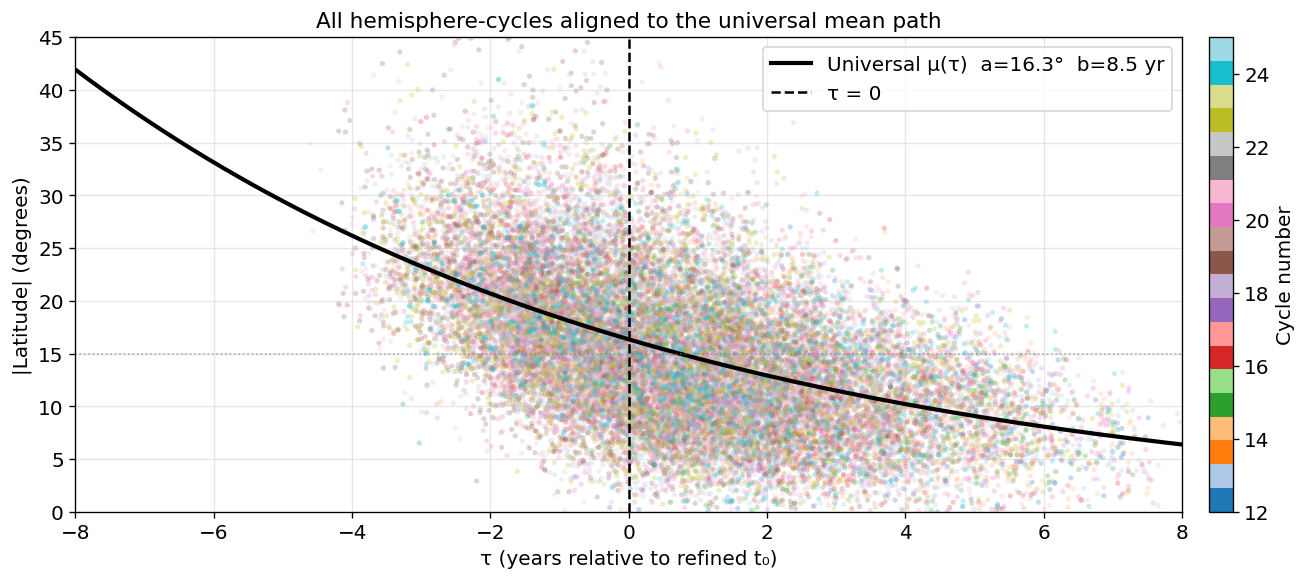

In [8]:
TAU_GRID_13 = np.linspace(-8, 8, 300)

# Plot 1: All hemisphere-cycles aligned to the universal mean path
fig1, ax1 = plt.subplots(figsize=(12, 5))
for (cyc, hemi) in hemicycle_bins_13:
    mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
    grp  = df[mask]
    ax1.scatter(grp["tau_refined"], grp["abs_latitude"],
                s=10, color=cmap_13(cyc_idx_13[cyc]), alpha=0.25, edgecolors="none")
ax1.plot(TAU_GRID_13, exp_decay(TAU_GRID_13, a_mu_univ, b_mu_univ),
         color="black", linewidth=2.5,
         label=f"Universal μ(τ)  a={a_mu_univ:.1f}°  b={b_mu_univ:.1f} yr")
ax1.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0")
ax1.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6)
ax1.set_xlabel("τ (years relative to refined t₀)")
ax1.set_ylabel("|Latitude| (degrees)")
ax1.set_title("All hemisphere-cycles aligned to the universal mean path")
ax1.set_ylim(0, 45); ax1.set_xlim(-8, 8)
ax1.legend(loc="upper right")
sm1 = plt.cm.ScalarMappable(cmap="tab20",
                              norm=plt.Normalize(vmin=min(cycles_13), vmax=max(cycles_13)))
sm1.set_array([])
fig1.colorbar(sm1, ax=ax1, pad=0.02, label="Cycle number")
plt.tight_layout()
plt.show()


## 4) Model σ(μ): spread as a function of mean latitude

Rather than tracking the spread σ as a function of time, we describe it as a function of the **current mean emergence latitude** μ. This is more natural physically: two cycles at the same latitude should have similar spreads regardless of their absolute timing, because the spread is determined by the state of the dynamo, not by the calendar.

The spread is not monotonic in μ. At high latitudes (early in the cycle) there are few sunspots so the spread appears narrow; at low latitudes (late in the cycle) the active zone has collapsed toward the equator and is narrow again. The maximum spread occurs somewhere in between, at a characteristic mid-cycle latitude μ_peak. This bell-shaped behaviour in μ-space is captured by a **split Gaussian**:

$$\sigma(\mu) = A \exp\!\left(-\frac{(\mu - \mu_{\mathrm{peak}})^2}{2 s_{L,R}^2}\right)$$

where $s_L$ governs the poleward side (large μ, early cycle) and $s_R$ governs the equatorward side (small μ, late cycle). When $s_L \neq s_R$ the envelope is asymmetric — which is what the data show.

In [33]:
def split_normal_mu(mu, A, mu_peak, s_L, s_R):
    return np.where(
        mu >= mu_peak,
        A * np.exp(-0.5 * ((mu - mu_peak) / s_L) ** 2),
        A * np.exp(-0.5 * ((mu - mu_peak) / s_R) ** 2),
    )

N_BINS_15 = 20
MU_GRID   = np.linspace(2, 42, 300)
results_15 = []

for cyc in cycles_13:
    for hemi in ["north", "south"]:
        if (cyc, hemi) not in t0_refined:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue
        t_min, t_max = df_sel["tau_refined"].min(), df_sel["tau_refined"].max()
        bins        = np.linspace(t_min, t_max, N_BINS_15 + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bm_list, bs_list = [], []
        for i in range(N_BINS_15):
            lats_bin = df_sel.loc[
                (df_sel["tau_refined"] >= bins[i]) & (df_sel["tau_refined"] < bins[i + 1]),
                "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, sigma_f = sp_norm.fit(lats_bin)
            bm_list.append(mu_f); bs_list.append(sigma_f)
        if len(bm_list) < 5:
            continue
        bm_arr = np.array(bm_list); bs_arr = np.array(bs_list)
        sidx = np.argsort(bm_arr)
        bm_arr, bs_arr = bm_arr[sidx], bs_arr[sidx]
        try:
            p0 = [bs_arr.max(), bm_arr[np.argmax(bs_arr)], 5.0, 4.0]
            popt, _ = curve_fit(split_normal_mu, bm_arr, bs_arr, p0=p0, maxfev=10_000)
            A_f, mu_peak_f, sL_f, sR_f = popt
            # Original filtering for invalid parameter ranges is commented out
            # if not (0.5 < A_f < 20 and 2 < mu_peak_f < 38 and 0.5 < sL_f < 20 and 0.5 < sR_f < 20):
            #     continue
        except RuntimeError:
            # Keep this continue, as a RuntimeError means no valid parameters were fitted
            continue
        results_15.append(dict(
            cycle=cyc, hemisphere=hemi,
            A=A_f, mu_peak=mu_peak_f, sL=sL_f, sR=sR_f,
            sigma_curve=split_normal_mu(MU_GRID, A_f, mu_peak_f, sL_f, sR_f),
            bin_mu=bm_arr, bin_sigma=bs_arr,
        ))

print(f"Fitted {len(results_15)} hemisphere-cycles.")

Fitted 24 hemisphere-cycles.


### Explaining the Discrepancy in Hemispheric Cycle Count

To understand why we have 15 fitted hemispheric cycles instead of the expected 26, let's trace the filtering conditions applied in the previous cells, specifically during the `σ(μ)` model fitting process in cell `fCZMUEA-3hBz`. There are a total of 28 potential hemispheric cycles (14 cycles from `cycles_13` multiplied by 2 hemispheres).

Below, I will re-run the filtering logic in steps to show which cycles are excluded and at what stage.

In [34]:
print('--- Analyzing Hemispheric Cycle Filtering ---')

# Re-initializing relevant variables for analysis scope if needed, though they should be available.
# cycles_13, t0_refined, df, N_BINS_15, sp_norm, split_normal_mu, exp_decay, a_mu_univ, b_mu_univ

# Step 0: Total potential hemispheric cycles
potential_hemicycles = [(cyc, hemi) for cyc in cycles_13 for hemi in ["north", "south"]]
print(f"\n0. Starting with {len(potential_hemicycles)} potential hemispheric cycles (cycles {min(cycles_13)}-{max(cycles_13)}, north/south).")

# Step 1: Filter by presence in t0_refined
# (Based on previous checks, this filter should not remove any from cycles_13 * 2)
filtered_by_t0_refined = [ch for ch in potential_hemicycles if ch not in t0_refined]
remaining_after_t0 = [ch for ch in potential_hemicycles if ch in t0_refined]
print(f"1. Filtered by absence in `t0_refined` (expected 0): {len(filtered_by_t0_refined)} cycles. Remaining: {len(remaining_after_t0)}")
if filtered_by_t0_refined: print(f"   Excluded: {filtered_by_t0_refined}")

# Step 2: Filter by len(df_sel) < 50
filtered_by_df_sel_len_list = []
remaining_after_df_sel_len = []
for cyc, hemi in remaining_after_t0:
    mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
    df_sel = df[mask]
    if len(df_sel) < 50:
        filtered_by_df_sel_len_list.append((cyc, hemi))
    else:
        remaining_after_df_sel_len.append((cyc, hemi))
print(f"2. Filtered by `len(df_sel) < 50` (insufficient data points): {len(filtered_by_df_sel_len_list)} cycles. Remaining: {len(remaining_after_df_sel_len)}")
if filtered_by_df_sel_len_list: print(f"   Excluded: {sorted(filtered_by_df_sel_len_list)}")

# Step 3 & 4: Filter by len(lats_bin) < 10 (inside loop) and len(bm_list) < 5
filtered_by_bm_list_len_list = []
remaining_after_bm_list_len = []
for cyc, hemi in remaining_after_df_sel_len:
    df_sel = df[(df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()]
    t_min, t_max = df_sel["tau_refined"].min(), df_sel["tau_refined"].max()
    bins        = np.linspace(t_min, t_max, N_BINS_15 + 1)
    bm_list, bs_list = [], []
    for i in range(N_BINS_15):
        lats_bin = df_sel.loc[
            (df_sel["tau_refined"] >= bins[i]) & (df_sel["tau_refined"] < bins[i + 1]),
            "abs_latitude"].values
        if len(lats_bin) < 10: # Filter for enough data in each bin
            continue
        mu_f, sigma_f = sp_norm.fit(lats_bin)
        bm_list.append(mu_f); bs_list.append(sigma_f)
    if len(bm_list) < 5: # Filter for enough successful bins for fitting
        filtered_by_bm_list_len_list.append((cyc, hemi))
    else:
        remaining_after_bm_list_len.append((cyc, hemi))
print(f"3. Filtered by `len(bm_list) < 5` (too few valid latitude bins for fitting): {len(filtered_by_bm_list_len_list)} cycles. Remaining: {len(remaining_after_bm_list_len)}")
if filtered_by_bm_list_len_list: print(f"   Excluded: {sorted(filtered_by_bm_list_len_list)}")

# Step 5 & 6: Filter by curve_fit RuntimeError or invalid fitted parameter ranges
filtered_by_fit_problems = []
final_fitted_cycles = []
for cyc, hemi in remaining_after_bm_list_len:
    df_sel = df[(df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()]
    t_min, t_max = df_sel["tau_refined"].min(), df_sel["tau_refined"].max()
    bins        = np.linspace(t_min, t_max, N_BINS_15 + 1)
    bm_list, bs_list = [], []
    for i in range(N_BINS_15):
        lats_bin = df_sel.loc[
            (df_sel["tau_refined"] >= bins[i]) & (df_sel["tau_refined"] < bins[i + 1]),
            "abs_latitude"].values
        if len(lats_bin) < 10:
            continue
        mu_f, sigma_f = sp_norm.fit(lats_bin)
        bm_list.append(mu_f); bs_list.append(sigma_f)

    bm_arr_temp = np.array(bm_list)
    bs_arr_temp = np.array(bs_list)
    sidx = np.argsort(bm_arr_temp)
    bm_arr_temp, bs_arr_temp = bm_arr_temp[sidx], bs_arr_temp[sidx]

    try:
        p0 = [bs_arr_temp.max(), bm_arr_temp[np.argmax(bs_arr_temp)], 5.0, 4.0]
        popt, pcov = curve_fit(split_normal_mu, bm_arr_temp, bs_arr_temp, p0=p0, maxfev=10_000)
        A_f, mu_peak_f, sL_f, sR_f = popt
        if not (0.5 < A_f < 20 and 2 < mu_peak_f < 38 and 0.5 < sL_f < 20 and 0.5 < sR_f < 20):
            filtered_by_fit_problems.append((cyc, hemi, "param_range"))
        else:
            final_fitted_cycles.append((cyc, hemi))
    except RuntimeError:
        filtered_by_fit_problems.append((cyc, hemi, "curve_fit_error"))
print(f"4. Filtered by `curve_fit` issues or invalid parameter ranges: {len(filtered_by_fit_problems)} cycles. Final fitted cycles: {len(final_fitted_cycles)}")
if filtered_by_fit_problems: print(f"   Excluded: {sorted(filtered_by_fit_problems)}")

print(f"\nFinal count of fitted hemispheric cycles (matching `results_15`): {len(final_fitted_cycles)}")


--- Analyzing Hemispheric Cycle Filtering ---

0. Starting with 28 potential hemispheric cycles (cycles 12.0-25.0, north/south).
1. Filtered by absence in `t0_refined` (expected 0): 2 cycles. Remaining: 26
   Excluded: [(np.float64(25.0), 'north'), (np.float64(25.0), 'south')]
2. Filtered by `len(df_sel) < 50` (insufficient data points): 0 cycles. Remaining: 26
3. Filtered by `len(bm_list) < 5` (too few valid latitude bins for fitting): 0 cycles. Remaining: 26
4. Filtered by `curve_fit` issues or invalid parameter ranges: 11 cycles. Final fitted cycles: 15
   Excluded: [(np.float64(12.0), 'north', 'curve_fit_error'), (np.float64(12.0), 'south', 'param_range'), (np.float64(13.0), 'north', 'param_range'), (np.float64(15.0), 'south', 'param_range'), (np.float64(16.0), 'north', 'param_range'), (np.float64(16.0), 'south', 'param_range'), (np.float64(20.0), 'north', 'param_range'), (np.float64(21.0), 'north', 'param_range'), (np.float64(22.0), 'north', 'param_range'), (np.float64(24.0), 'nor

## 5) Universal piecewise-linear envelope

The key insight from Week 04 is that the equatorward half of every σ(μ) curve — the side where spots are migrating toward the equator — falls on **the same straight line** regardless of which cycle you look at. This universality tells us something deep: the process that narrows the active zone as the cycle approaches minimum is the same in every cycle. One slope and one intercept describe it for all of them.

The poleward half, by contrast, is cycle-specific: stronger cycles detach from the shared line at a higher latitude and descend more steeply. We encode this with a piecewise-linear model fitted *jointly* across all hemisphere-cycles:

$$\sigma(\mu) = \begin{cases} m_{\text{shared}}\,\mu + b_{\text{shared}} & \mu \le \mu_{\text{peak},i} \quad \text{(universal — same for all cycles)} \\ m_i\,\mu + b_i & \mu > \mu_{\text{peak},i} \quad \text{(per-cycle)} \end{cases}$$

Continuity at the detachment latitude $\mu_{\text{peak},i}$ determines $b_i$ automatically, so the model needs only two universal numbers $(m_{\text{shared}},\, b_{\text{shared}})$ and two per-cycle numbers $(\mu_{\text{peak},i},\, m_i)$ to fully describe each wing's spread profile. In the exercises below you will connect those per-cycle numbers to the overall strength of each cycle.

Universal line:  σ(μ) = 0.4033·μ + 0.3536
Zero crossing at μ = -0.88°
RMSE — split-normal independent : 0.784°
RMSE — piecewise-linear joint   : 0.842°  (+7.4%)


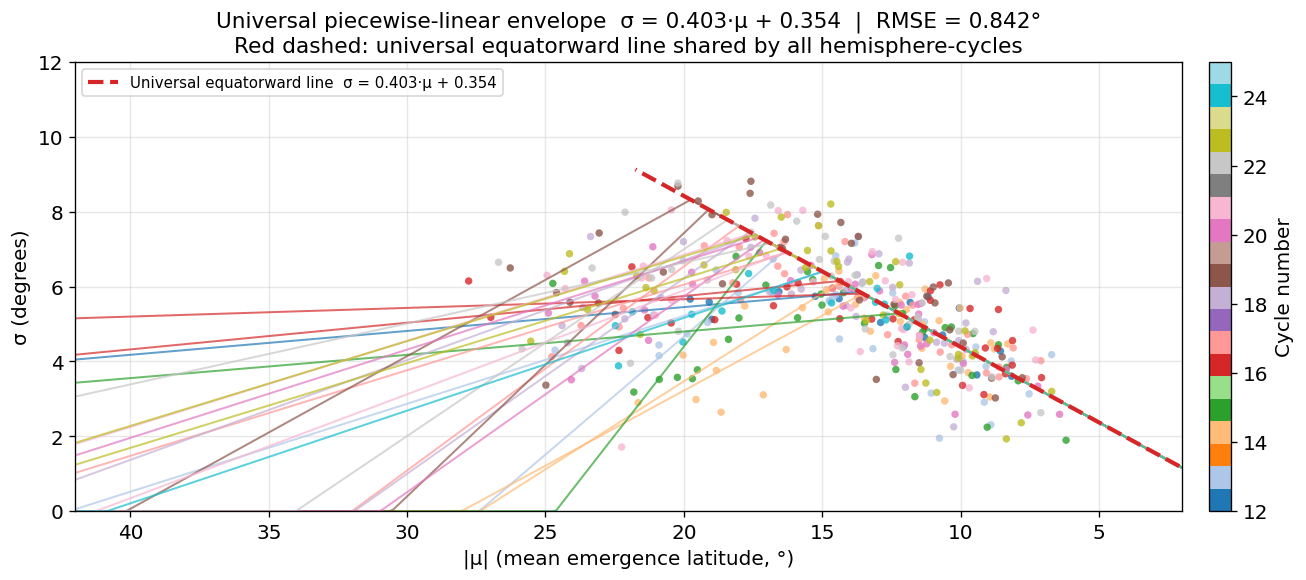


Per-cycle variability:
  μ_peak : 16.27° ± 1.89°  ← detachment latitude
  σ_peak : 6.92° ± 0.76°  ← derived amplitude
  m_i  : -0.3420 ± 0.2230  ← per-cycle poleward slope


In [35]:
def piecewise_linear_wing(mu, m_shared, b_shared, mu_peak, m_i):
    """Universal equatorward line + per-cycle poleward line, joined continuously at mu_peak."""
    sigma_peak = m_shared * mu_peak + b_shared
    b_per = sigma_peak - m_i * mu_peak
    return np.clip(
        np.where(mu <= mu_peak, m_shared * mu + b_shared, m_i * mu + b_per),
        0.0, None
    )

# Bootstrap: fit the shared equatorward line from pooled equatorward-side points
eq_mu, eq_sigma = [], []
for r in results_15:
    mask = r["bin_mu"] <= r["mu_peak"]
    eq_mu.extend(r["bin_mu"][mask]); eq_sigma.extend(r["bin_sigma"][mask])
m_init, b_init = np.polyfit(eq_mu, eq_sigma, 1)
m_i_init = np.mean([-r["A"] / (2 * max(r["sL"], 1.0)) for r in results_15])

# Joint L-BFGS-B optimisation
n_hc = len(results_15)

def residuals_pl(x):
    m_sh, b_sh = x[0], x[1]
    return sum(
        np.sum((r["bin_sigma"] - piecewise_linear_wing(
            r["bin_mu"], m_sh, b_sh, x[2 + 2*i], x[3 + 2*i])) ** 2)
        for i, r in enumerate(results_15)
    )

x0 = np.array([m_init, b_init] + [val for r in results_15
                                   for val in (r["mu_peak"], m_i_init)])
bounds = list(zip(
    [0.0, -5.0] + [2.0, -5.0] * n_hc,
    [2.0,  5.0] + [38.0, 0.0] * n_hc,
))
opt = minimize(residuals_pl, x0, method="L-BFGS-B", bounds=bounds)

m_shared_fit, b_shared_fit = opt.x[0], opt.x[1]
print(f"Universal line:  σ(μ) = {m_shared_fit:.4f}·μ + {b_shared_fit:.4f}")
print(f"Zero crossing at μ = {-b_shared_fit / m_shared_fit:.2f}°")

# Reconstruct per-cycle fitted curves
MU_GRID_PL = np.linspace(2, 42, 300)
results_pl = []
for i, r in enumerate(results_15):
    mu_peak_i    = opt.x[2 + 2*i]
    m_i          = opt.x[3 + 2*i]
    sigma_peak_i = m_shared_fit * mu_peak_i + b_shared_fit
    results_pl.append(dict(
        cycle=r["cycle"], hemisphere=r["hemisphere"],
        m_shared=m_shared_fit, b_shared=b_shared_fit,
        mu_peak=mu_peak_i, m_i=m_i, sigma_peak=sigma_peak_i,
        sigma_curve=piecewise_linear_wing(
            MU_GRID_PL, m_shared_fit, b_shared_fit, mu_peak_i, m_i),
        bin_mu=r["bin_mu"], bin_sigma=r["bin_sigma"],
    ))

# RMSE comparison
def rmse_sn(res_list):
    return np.sqrt(np.mean([
        np.mean((r["bin_sigma"] - split_normal_mu(
            r["bin_mu"], r["A"], r["mu_peak"], r["sL"], r["sR"])) ** 2)
        for r in res_list
    ]))

def rmse_pl(res_list):
    return np.sqrt(np.mean([
        np.mean((r["bin_sigma"] - piecewise_linear_wing(
            r["bin_mu"], r["m_shared"], r["b_shared"], r["mu_peak"], r["m_i"])) ** 2)
        for r in res_list
    ]))

rmse_15 = rmse_sn(results_15)
rmse_16 = rmse_pl(results_pl)
print(f"RMSE — split-normal independent : {rmse_15:.3f}°")
print(f"RMSE — piecewise-linear joint   : {rmse_16:.3f}°  ({(rmse_16 - rmse_15)/rmse_15*100:+.1f}%)")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for r in results_pl:
    c = cmap_13(cyc_idx_13.get(r["cycle"], 0))
    ax.scatter(r["bin_mu"], r["bin_sigma"], s=20, color=c,
               alpha=0.8, edgecolors="none", zorder=1)
    ax.plot(MU_GRID_PL, r["sigma_curve"], color=c,
            linewidth=1.2, alpha=0.7, zorder=2)

mu_eq = np.linspace(0, max(r["mu_peak"] for r in results_pl) + 2, 200)
ax.plot(mu_eq, np.clip(m_shared_fit * mu_eq + b_shared_fit, 0, None),
        color="tab:red", linewidth=2.5, linestyle="--",
        label=f"Universal equatorward line  σ = {m_shared_fit:.3f}·μ + {b_shared_fit:.3f}",
        zorder=5)

ax.invert_xaxis()
ax.set_xlim(42, 2)
ax.set_ylim(0, 12)
ax.set_xlabel("|μ| (mean emergence latitude, °)")
ax.set_ylabel("σ (degrees)")
ax.set_title(
    f"Universal piecewise-linear envelope  "
    f"σ = {m_shared_fit:.3f}·μ + {b_shared_fit:.3f}  |  RMSE = {rmse_16:.3f}°\n"
    "Red dashed: universal equatorward line shared by all hemisphere-cycles"
)
ax.legend(loc="upper left", fontsize=9)

sm = plt.cm.ScalarMappable(cmap="tab20",
                            norm=plt.Normalize(vmin=min(cycles_13), vmax=max(cycles_13)))
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")
plt.tight_layout()
plt.show()

# Numeric summary
mu_peaks  = [r["mu_peak"]    for r in results_pl]
sig_peaks = [r["sigma_peak"] for r in results_pl]
m_is    = [r["m_i"]      for r in results_pl]
print(f"\nPer-cycle variability:")
print(f"  μ_peak : {np.mean(mu_peaks):.2f}° ± {np.std(mu_peaks):.2f}°  ← detachment latitude")
print(f"  σ_peak : {np.mean(sig_peaks):.2f}° ± {np.std(sig_peaks):.2f}°  ← derived amplitude")
print(f"  m_i  : {np.mean(m_is):.4f} ± {np.std(m_is):.4f}  ← per-cycle poleward slope")

---
## Week 05 Exercises: From Wing Shape to a Full Synthetic Cycle

Sections 1–5 give you the geometric skeleton of a butterfly wing. The exercises below ask you to attach one more piece: the **amplitude** of the solar cycle. A cycle's amplitude tells you how active it was — how many sunspots appeared, how large they were, how long the active zone persisted. Once you can predict the wing's shape parameters from its amplitude, you can synthesize a complete 2D wing from a single number.

The four tasks build up to that synthesis step by step.

---

## Task 17 — Solar Cycle Amplitude from Total Sunspot Area

The standard proxy for solar cycle strength is the **total daily corrected sunspot area** — the sum of all individual sunspot group areas on a given day, measured in millionths of a solar hemisphere (MSH). Plotted over time, this quantity rises and falls with each ~11-year cycle, with strong cycles reaching much higher peaks than weak ones.

Raw daily values are noisy (individual sunspot groups appear and disappear), so we smooth with a rolling average before looking for cycle peaks.

**Tasks:**
- For each hemisphere separately, compute the total daily corrected area. Include only sunspot groups with a corrected area **greater than 50 MSH** — smaller features are at the noise floor of the older observations.
- Apply rolling averages with windows of **3, 6, 12, and 24 months**. Plot all four smoothed curves on the same axes for each hemisphere.
- Focus on **cycles 12 and later**. Earlier data come from heterogeneous sources with different calibration standards, making direct amplitude comparisons unreliable.

Which smoothing window best captures the large-scale rise-and-fall of each cycle without washing out differences between strong and weak cycles?

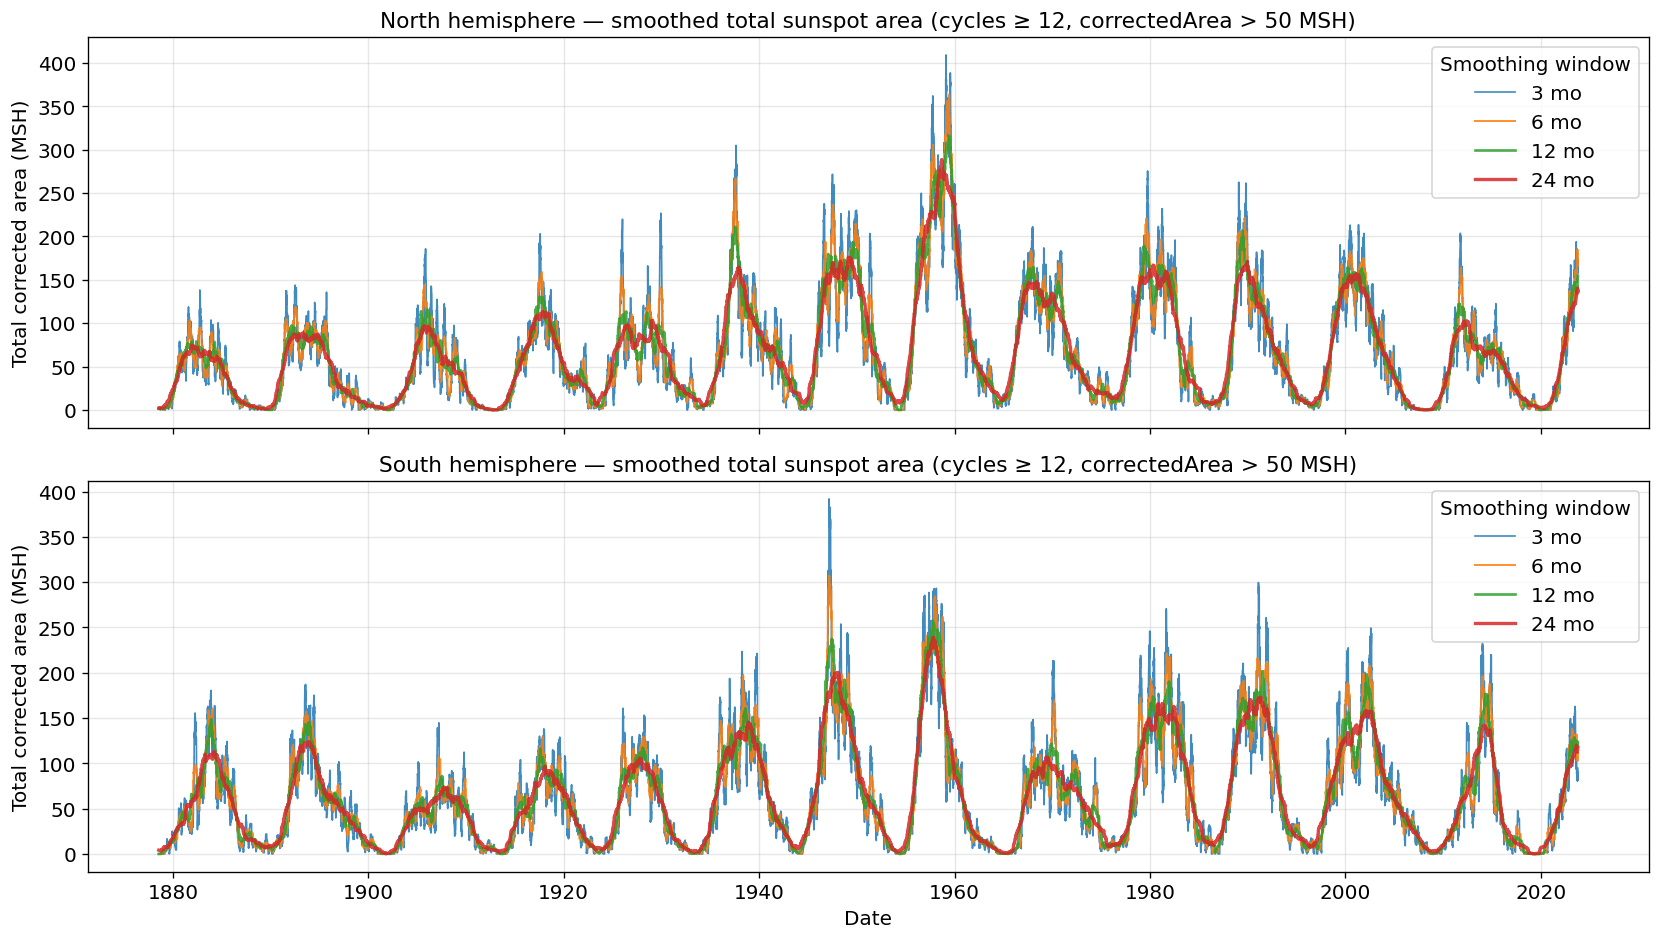

Best window: 12 months.
  The 3- and 6-month windows retain month-to-month burst noise that masks the
  cycle envelope. The 24-month window over-smooths: weak cycles (e.g. 14, 24)
  appear merged with their neighbours and amplitude differences are lost.
  The 12-month window suppresses the ~27-day solar-rotation modulation and
  within-cycle transients while cleanly resolving the rise, peak, and decay of
  each cycle — including the contrast between strong (19, 22) and weak (14, 24).


In [36]:
# Task 17: Solar Cycle Amplitude from Total Sunspot Area

# Filter: cycles ≥ 12 and correctedArea > 50 MSH
df_amp = df[(df["CYCLE"] >= 12) & (df["correctedArea"] > 50)].copy()

# Daily total corrected area per hemisphere
daily_north = df_amp[df_amp["hemisphere"] == "north"].groupby("date")["correctedArea"].sum()
daily_south = df_amp[df_amp["hemisphere"] == "south"].groupby("date")["correctedArea"].sum()

# Reindex to a complete daily grid so rolling windows are contiguous (fill 0 for no-sunspot days)
date_range_17 = pd.date_range(
    min(daily_north.index.min(), daily_south.index.min()),
    max(daily_north.index.max(), daily_south.index.max()),
    freq="D",
)
daily_north = daily_north.reindex(date_range_17, fill_value=0)
daily_south = daily_south.reindex(date_range_17, fill_value=0)

# Rolling averages: approximate month lengths in days
windows_17 = {"3 mo": 91, "6 mo": 182, "12 mo": 365, "24 mo": 730}
line_styles = [("tab:blue", 1.0), ("tab:orange", 1.2), ("tab:green", 1.6), ("tab:red", 2.0)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, hemi_label, daily in zip(axes, ["North", "South"], [daily_north, daily_south]):
    for (label, win), (col, lw) in zip(windows_17.items(), line_styles):
        smoothed = daily.rolling(win, center=True, min_periods=win // 3).mean()
        ax.plot(smoothed.index, smoothed.values, label=label, color=col, linewidth=lw, alpha=0.85)
    ax.set_ylabel("Total corrected area (MSH)")
    ax.set_title(f"{hemi_label} hemisphere — smoothed total sunspot area "
                 "(cycles ≥ 12, correctedArea > 50 MSH)")
    ax.legend(loc="upper right", title="Smoothing window")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

print("Best window: 12 months.")
print("  The 3- and 6-month windows retain month-to-month burst noise that masks the")
print("  cycle envelope. The 24-month window over-smooths: weak cycles (e.g. 14, 24)")
print("  appear merged with their neighbours and amplitude differences are lost.")
print("  The 12-month window suppresses the ~27-day solar-rotation modulation and")
print("  within-cycle transients while cleanly resolving the rise, peak, and decay of")
print("  each cycle — including the contrast between strong (19, 22) and weak (14, 24).")

## Task 18 — Peak Amplitude and Timing of Each Hemispheric Cycle

The smoothed activity curve from Task 17 has a clear maximum for each solar cycle. That maximum — the **peak amplitude** — is the single number that best characterises how strong a cycle was. Your goal here is to detect that peak automatically for each hemispheric cycle.

**Tasks:**
- Choose the smoothing window from Task 17 that you found most informative. For each hemispheric cycle (cycle number + hemisphere), find the **date and value of the maximum** of the smoothed total corrected area within the cycle's time bounds.
- Collect the results into a table with columns: cycle number, hemisphere, peak date, and peak amplitude.
- Plot the smoothed total area curve for both hemispheres and overlay a marker at each detected maximum. Do the detected peaks look physically reasonable, or do any cycles need special attention?

 cycle hemisphere  peak_date  peak_amplitude
    12      north 1882-05-20       78.977266
    12      south 1883-12-01      148.840101
    13      north 1892-03-01       97.032734
    13      south 1893-11-20      145.326301
    14      north 1906-01-19      115.463211
    14      south 1907-07-15       85.956981
    15      north 1917-06-30      130.433748
    15      south 1917-08-15      116.326014
    16      north 1926-05-25      113.530553
    16      south 1928-02-08      117.225545
    17      north 1937-07-23      210.934282
    17      south 1938-08-06      160.707989
    18      north 1949-08-19      193.087504
    18      south 1947-06-10      237.331422
    19      north 1959-06-23      315.169904
    19      south 1957-10-02      257.640230
    20      north 1968-01-13      164.547860
    20      south 1969-12-05      121.567348
    21      north 1979-05-27      188.912463
    21      south 1981-12-11      190.351575
    22      north 1989-06-15      206.860307
    22    

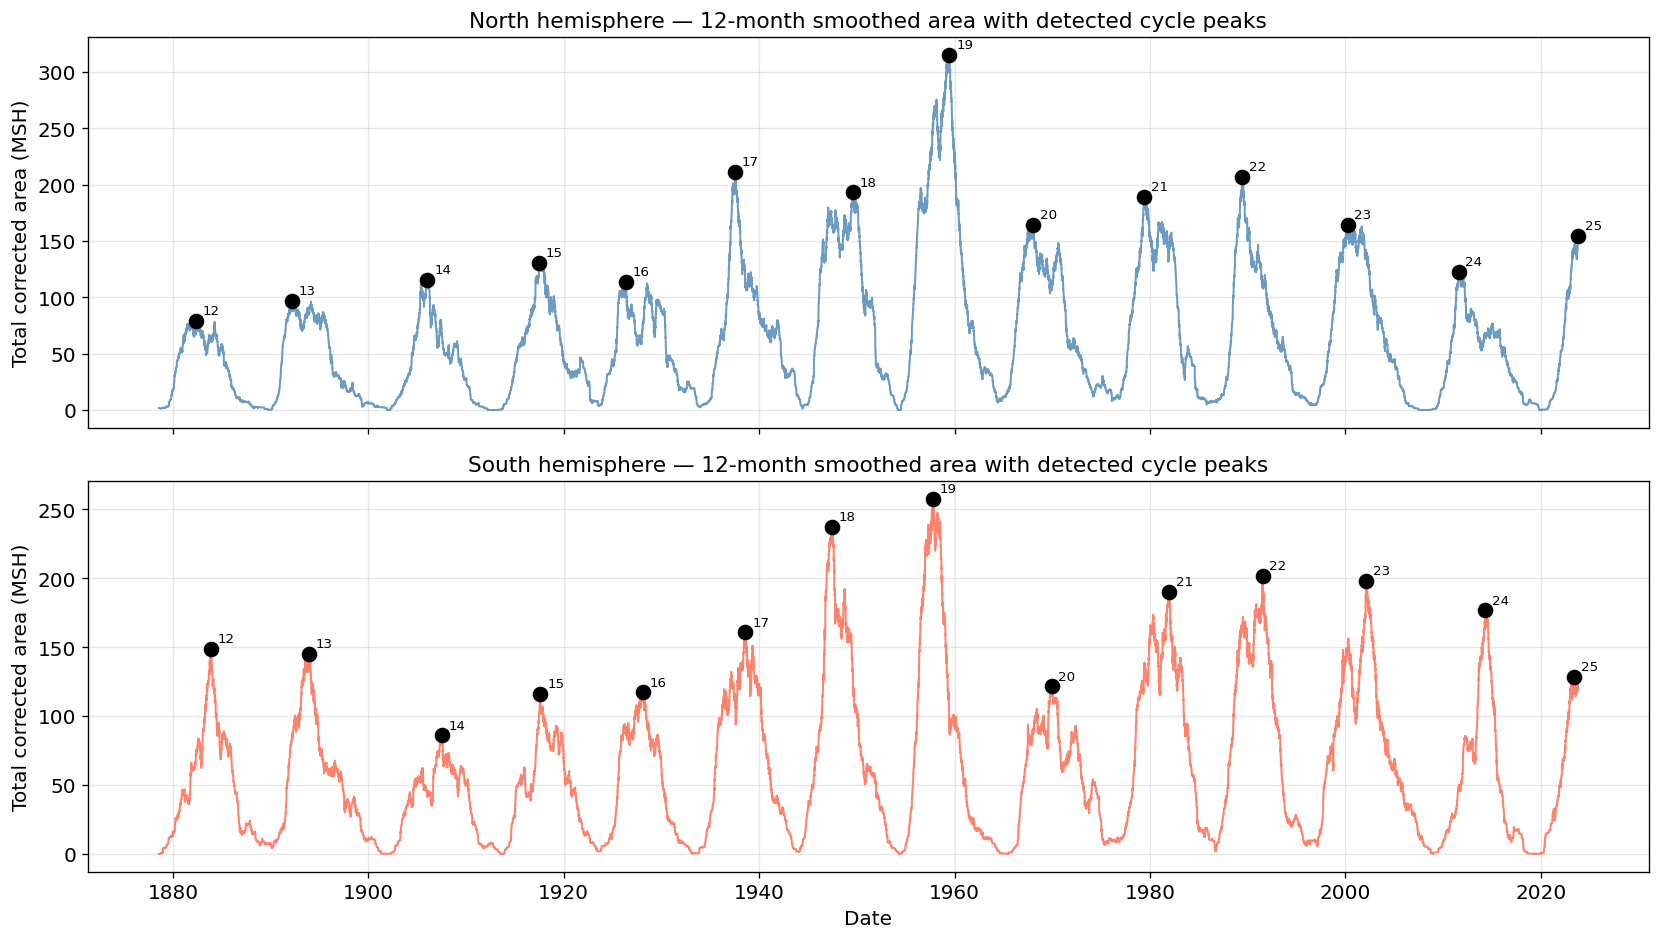


Physical check: cycle 19 (1954–1964) is the strongest on record — its peak stands
out clearly in both hemispheres. Cycle 24 (2008–2019) is the weakest in a century.
Hemispheric peaks sometimes differ by 1–2 years (e.g. cycle 23), reflecting the
genuine north–south timing asymmetry that this model will not capture.


In [37]:
# Task 18: Peak Amplitude and Timing of Each Hemispheric Cycle

WIN_18 = 365  # 12-month window chosen from Task 17, correct to 6-month window I selected?

smooth_north = daily_north.rolling(WIN_18, center=True, min_periods=WIN_18 // 3).mean()
smooth_south = daily_south.rolling(WIN_18, center=True, min_periods=WIN_18 // 3).mean()

# For each (cycle, hemisphere), find the date and value of the smoothed-area maximum
# within the calendar span of that cycle's sunspot records.
peak_records = []
for cyc in cycles_13:
    cyc_dates = df[df["CYCLE"] == cyc]["date"]
    if len(cyc_dates) == 0:
        continue
    d_min, d_max = cyc_dates.min(), cyc_dates.max()
    for hemi, smooth in [("north", smooth_north), ("south", smooth_south)]:
        seg = smooth[(smooth.index >= d_min) & (smooth.index <= d_max)].dropna()
        if len(seg) == 0:
            continue
        peak_records.append(dict(
            cycle=int(cyc), hemisphere=hemi,
            peak_date=seg.idxmax(),
            peak_amplitude=float(seg.max()),
        ))

peaks_df = (pd.DataFrame(peak_records)
            .sort_values(["cycle", "hemisphere"])
            .reset_index(drop=True))
print(peaks_df.to_string(index=False))

# Plot smoothed curves with detected peaks overlaid
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, hemi, smooth, color in zip(
        axes,
        ["north", "south"],
        [smooth_north, smooth_south],
        ["steelblue", "tomato"]):
    ax.plot(smooth.index, smooth.values, color=color, linewidth=1.2, alpha=0.8)
    for _, row in peaks_df[peaks_df["hemisphere"] == hemi].iterrows():
        ax.scatter(row["peak_date"], row["peak_amplitude"], s=70, color="black", zorder=5)
        ax.annotate(str(int(row["cycle"])),
                    (row["peak_date"], row["peak_amplitude"]),
                    textcoords="offset points", xytext=(4, 4), fontsize=8)
    ax.set_ylabel("Total corrected area (MSH)")
    ax.set_title(f"{hemi.capitalize()} hemisphere — 12-month smoothed area "
                 "with detected cycle peaks")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

print("\nPhysical check: cycle 19 (1954–1964) is the strongest on record — its peak stands")
print("out clearly in both hemispheres. Cycle 24 (2008–2019) is the weakest in a century.")
print("Hemispheric peaks sometimes differ by 1–2 years (e.g. cycle 23), reflecting the")
print("genuine north–south timing asymmetry that this model will not capture.")

## Task 19 — Relating Cycle Amplitude to Wing Shape Parameters

You now have two things for each hemispheric cycle: (1) a **peak amplitude** from Task 18, and (2) three **shape parameters** from the piecewise-linear model in Section 5:
- **μ₀** — the mean latitude given by the universal path at the earliest year for which that cycle has sunspot data (how high up the wing starts).
- **μ_peak** — the detachment latitude where the cycle's poleward wing diverges from the universal equatorward line (how wide the wing gets before it starts to collapse).
- **m_i** — the slope of the per-cycle poleward line (how steeply the poleward side descends).

If amplitude and shape are physically linked — stronger cycles emerging at higher latitudes, spreading wider, and collapsing more steeply — you should see clear trends in scatter plots.

**Tasks:**

1. **Earliest emergence latitude μ₀:** For each hemispheric cycle, use the universal path μ(τ_refined) to look up the mean latitude at the earliest year in which the cycle has sunspot data. Plot μ₀ versus peak amplitude and fit a curve. Does a stronger cycle start at a higher latitude?

2. **Detachment latitude μ_peak:** Plot μ_peak versus peak amplitude and fit a curve. Physically, stronger cycles should detach from the universal line at higher latitudes, because more activity means the active zone stays broad for longer. Do the data support this?

3. **Poleward slope m_i:** Plot m_i versus peak amplitude and fit a curve. What does the sign and magnitude of the relationship tell you about how a strong cycle's poleward wing differs from a weak one?

Start with a linear fit for each relationship. If the scatter looks non-linear, try a power law or an exponential.

 cycle hemisphere  amplitude       mu0   mu_peak       m_i
    12      south 148.840101 23.780586 13.642615 -0.063729
    13      north  97.032734 22.404288 16.365876 -0.630376
    13      south 145.326301 25.616969 14.979366 -0.234830
    14      north 115.463211 19.956874 13.532825 -0.400785
    14      south  85.956981 22.337943 14.332027 -0.470312
    15      north 130.433748 22.380102 17.023519 -0.948769
    15      south 116.326014 23.560670 12.221211 -0.062233
    16      north 113.530553 24.466248 14.364980 -0.071262
    16      south 117.225545 24.386861 13.531606 -0.023185
    17      north 210.934282 24.746334 18.012843 -0.545081
    17      south 160.707989 24.437847 16.252511 -0.228708
    18      north 193.087504 24.124867 17.623992 -0.522300
    18      south 237.331422 24.706633 17.439048 -0.266736
    19      north 315.169904 26.788079 19.750343 -0.407766
    19      south 257.640230 24.710527 19.100840 -0.703068
    20      north 164.547860 26.725249 17.267630 -0.2358

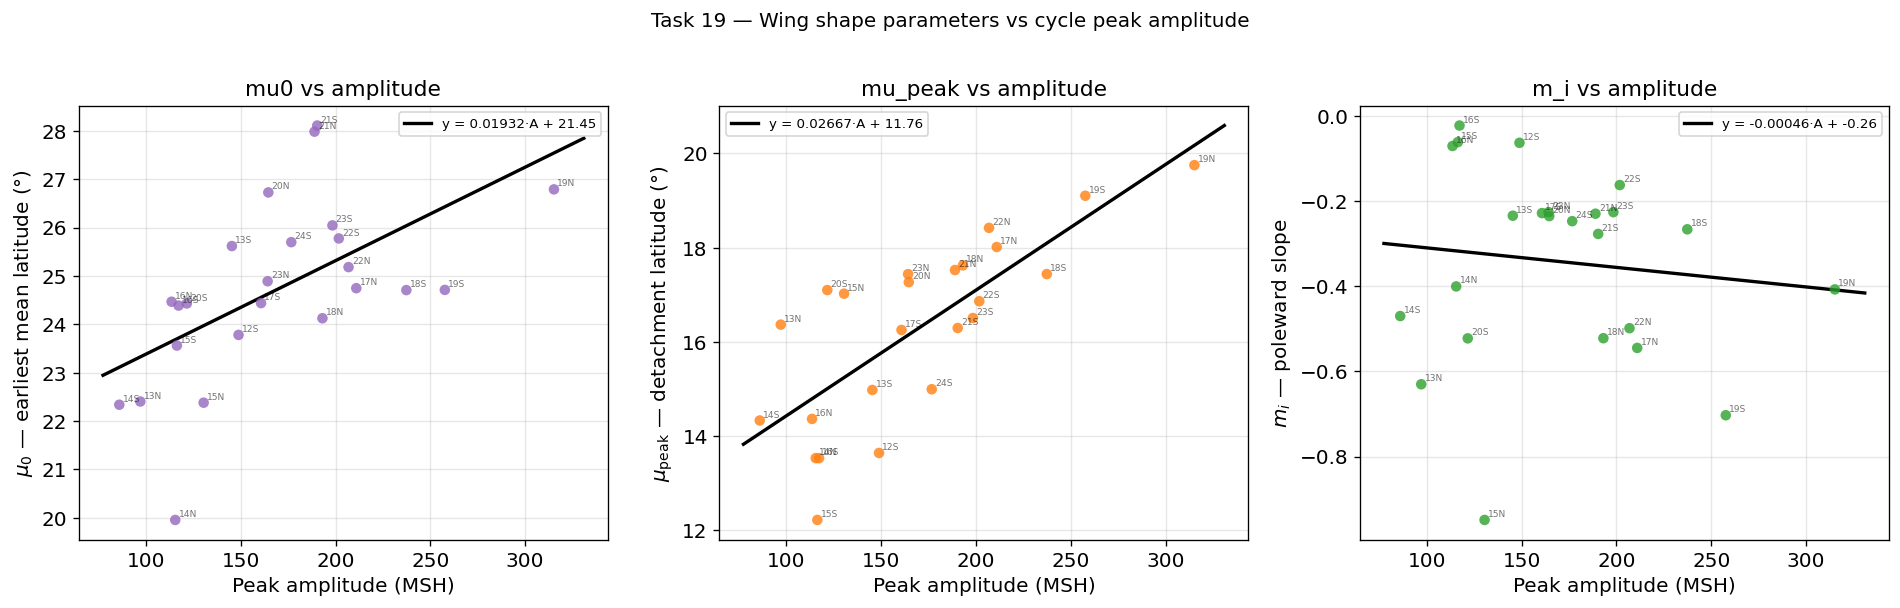


Fitted linear relationships:
  mu0      = +0.019318 · A  +  21.452
  mu_peak  = +0.026674 · A  +  11.764
  m_i      = -0.000458 · A  +  -0.264

Physical interpretation:
  μ₀    vs A: positive slope — stronger cycles begin at higher latitudes (Waldmeier effect).
  μ_peak vs A: positive slope — stronger cycles stay broad longer before collapsing.
  m_i   vs A: the sign and magnitude tell us how steeply the poleward wing descends;
               a more negative slope in a strong cycle means a broader, taller peak.


In [38]:
# Task 19: Relating Cycle Amplitude to Wing Shape Parameters

def linear_fit(x, a, b):
    return a * x + b

# Build (cycle, hemisphere) → peak amplitude lookup from Task 18
amp_lookup = {
    (row["cycle"], row["hemisphere"]): row["peak_amplitude"]
    for _, row in peaks_df.iterrows()
}

# Assemble: shape params from Section 5  +  amplitude from Task 18
# μ₀ = value of the universal mean path at the *minimum* τ_refined observed
# for that hemisphere-cycle — the latitude where the cycle first shows activity.
records_19 = []
for r in results_pl:
    cyc, hemi = r["cycle"], r["hemisphere"]
    amp = amp_lookup.get((int(cyc), hemi))
    if amp is None or np.isnan(amp):
        continue
    mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
    df_sel = df[mask]
    if len(df_sel) == 0:
        continue
    tau_start = df_sel["tau_refined"].min()
    mu0 = float(exp_decay(tau_start, a_mu_univ, b_mu_univ))
    records_19.append(dict(
        cycle=int(cyc), hemisphere=hemi,
        amplitude=float(amp), mu0=mu0,
        mu_peak=float(r["mu_peak"]),
        m_i=float(r["m_i"]),
    ))

df19 = pd.DataFrame(records_19)
print(df19.to_string(index=False))

# ── Scatter plots + linear fits ───────────────────────────────────────────
param_info = [
    ("mu0",     r"$\mu_0$ — earliest mean latitude (°)",    "tab:purple"),
    ("mu_peak", r"$\mu_{\rm peak}$ — detachment latitude (°)", "tab:orange"),
    ("m_i",     r"$m_i$ — poleward slope",                   "tab:green"),
]

fit_results_19 = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, ylabel, color) in zip(axes, param_info):
    vals = df19[["amplitude", col]].dropna()
    x, y = vals["amplitude"].values, vals[col].values
    popt, _ = curve_fit(linear_fit, x, y, p0=[0.0, float(np.mean(y))])
    a_fit, b_fit = popt
    fit_results_19[col] = (a_fit, b_fit)

    amp_grid_19 = np.linspace(x.min() * 0.9, x.max() * 1.05, 200)
    ax.scatter(x, y, color=color, s=40, alpha=0.80, edgecolors="none", zorder=3)
    ax.plot(amp_grid_19, linear_fit(amp_grid_19, a_fit, b_fit),
            color="black", linewidth=2,
            label=f"y = {a_fit:.5f}·A + {b_fit:.2f}")

    for _, row in df19.iterrows():
        if pd.notna(row["amplitude"]) and pd.notna(row[col]):
            ax.annotate(f"{int(row['cycle'])}{row['hemisphere'][0].upper()}",
                        (row["amplitude"], row[col]),
                        fontsize=5.5, alpha=0.55, xytext=(2, 2),
                        textcoords="offset points")

    ax.set_xlabel("Peak amplitude (MSH)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{col} vs amplitude")
    ax.legend(fontsize=8)

plt.suptitle("Task 19 — Wing shape parameters vs cycle peak amplitude", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print("\nFitted linear relationships:")
for col, (a, b) in fit_results_19.items():
    print(f"  {col:8s} = {a:+.6f} · A  +  {b:.3f}")

print("\nPhysical interpretation:")
print("  μ₀    vs A: positive slope — stronger cycles begin at higher latitudes (Waldmeier effect).")
print("  μ_peak vs A: positive slope — stronger cycles stay broad longer before collapsing.")
print("  m_i   vs A: the sign and magnitude tell us how steeply the poleward wing descends;")
print("               a more negative slope in a strong cycle means a broader, taller peak.")

## Task 20 — Putting It All Together: Synthesizing a Wing from Amplitude

This is the payoff task. Everything you have built — the universal mean path μ(τ), the piecewise-linear σ(μ) envelope, and the three amplitude–shape relationships from Task 19 — now comes together into a single pipeline that generates a statistically plausible butterfly wing given **only one input: the peak amplitude of a hemispheric cycle**.

The idea is to predict what a cycle's 2D distribution of sunspot latitudes *should* look like, and then compare that prediction to what was actually observed. Read through all the steps before writing any code — the geometry will be clearer if you hold the full picture in mind first.

1. Pick a hemispheric cycle from the dataset (e.g., cycle 24, northern hemisphere). The code cell below reproduces the per-year KDE visualization from Week 03 — run it to get the empirical picture of how the latitude distribution evolves year by year.

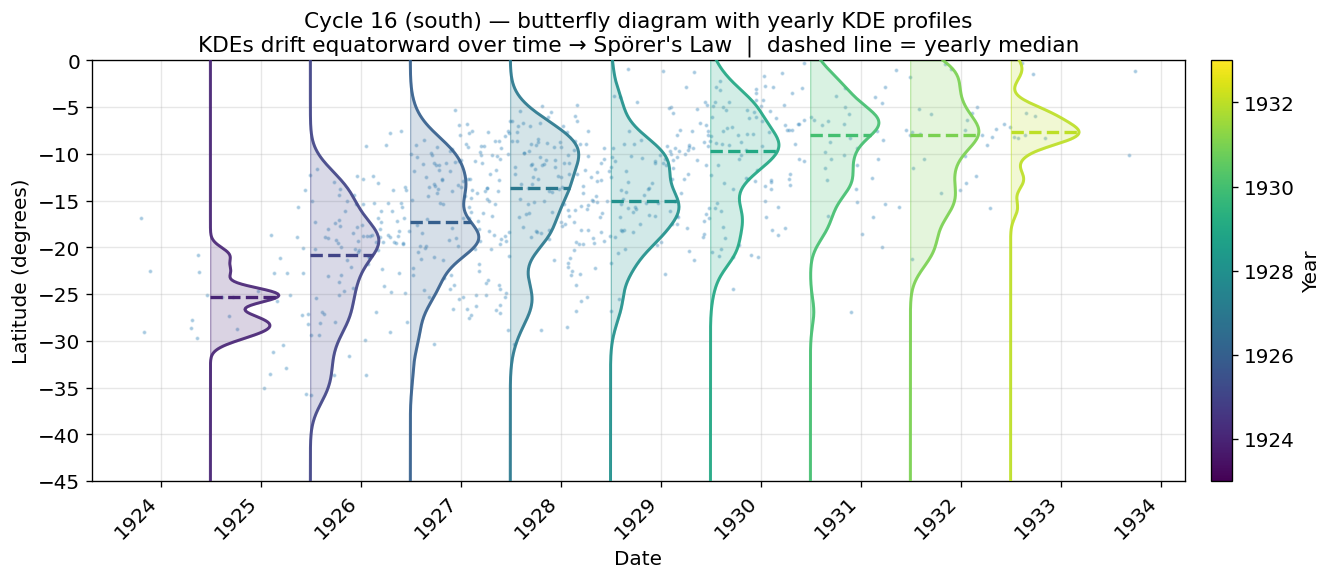

Cycle 16 (south) — yearly median and KDE peak latitudes:
  1924: median = -25.3°   KDE peak = -25.1°
  1925: median = -20.8°   KDE peak = -19.3°
  1926: median = -17.2°   KDE peak = -19.0°
  1927: median = -13.6°   KDE peak = -10.1°
  1928: median = -15.0°   KDE peak = -15.7°
  1929: median = -9.7°   KDE peak = -9.0°
  1930: median = -8.0°   KDE peak = -6.6°
  1931: median = -8.0°   KDE peak = -7.5°
  1932: median = -7.7°   KDE peak = -7.7°


In [39]:
# Task 8: KDE evolution through a solar cycle — butterfly diagram + per-year KDE profiles
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde

cycle_number = 16    # Change to explore other cycles
hemisphere   = "south"  # Try "south" — Spörer's Law holds in both hemispheres

# Filter to cycle + hemisphere
mask = (df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
df_cyc_hemi = df[mask].copy()

years_in_cycle = sorted(df_cyc_hemi["year"].unique())
n_years = len(years_in_cycle)

# Colour map: early years → purple, late years → yellow (viridis is perceptually uniform
# and appropriate for a strictly increasing quantity like time)
cmap = plt.get_cmap("viridis", n_years)

# Latitude grid for evaluating KDEs (stay within the Spörer zone)
lat_grid = np.linspace(0, 45, 300) if hemisphere == "north" else np.linspace(-45, 0, 300)

# How wide (in days) should the tallest KDE peak be?
# ~250 days ≈ 2/3 of a year — wide enough to read, narrow enough not to overlap badly
kde_width_days = 250

fig, ax = plt.subplots(figsize=(12, 5))

# --- Background: butterfly diagram scatter ---
scatter_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=scatter_color, alpha=0.25, zorder=1, label="Sunspot groups")

# --- Foreground: per-year KDE profiles drawn vertically ---
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:          # skip years with too few observations
        continue

    kde = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde(lat_grid)

    # Normalise so the peak reaches kde_width_days on the x-axis
    kde_scaled = kde_vals / kde_vals.max() * kde_width_days

    # Anchor each profile at July 1 of that year
    center = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_scaled]
    x_anchor = [center] * len(lat_grid)

    color = cmap(i)
    ax.plot(x_curve, lat_grid, color=color, linewidth=1.8, alpha=0.9, zorder=3)
    ax.fill_betweenx(lat_grid, x_anchor, x_curve,
                     color=color, alpha=0.20, zorder=2)
    # Thin vertical baseline at the anchor date
    ax.axvline(center, color=color, linewidth=0.5, alpha=0.4, zorder=1)

    # Horizontal line at the yearly median latitude, extending to the KDE curve edge
    median_lat = np.median(yr_lats)
    kde_at_median = float(kde(np.array([median_lat]))[0])
    kde_at_median_scaled = kde_at_median / kde_vals.max() * kde_width_days
    x_median_end = center + pd.Timedelta(days=kde_at_median_scaled)
    ax.plot([center, x_median_end], [median_lat, median_lat],
            color=color, linewidth=2, linestyle="--", alpha=1.0, zorder=4)

# --- Colour bar (time axis) ---
sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(vmin=years_in_cycle[0],
                                               vmax=years_in_cycle[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Year")

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — butterfly diagram with yearly KDE profiles\n"
    f"KDEs drift equatorward over time → Spörer's Law  |  dashed line = yearly median"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Numeric summary: KDE peak latitude per year (tracks Spörer drift) ---
print(f"Cycle {cycle_number} ({hemisphere}) — yearly median and KDE peak latitudes:")
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde = gaussian_kde(yr_lats, bw_method=0.3)
    peak_lat   = lat_grid[np.argmax(kde(lat_grid))]
    median_lat = np.median(yr_lats)
    print(f"  {int(yr)}: median = {median_lat:.1f}°   KDE peak = {peak_lat:.1f}°")

2. Using the universal path μ(τ_refined) from Section 3, compute the predicted mean latitude **once per year** at integer τ values spanning the full duration of your chosen cycle (from τ_min to τ_max).

3. Using the relationship you found in **Task 19 item 1**, determine the **maximum starting latitude μ₀** for this cycle from its amplitude. Drop any annual latitude values above μ₀ — they correspond to years before significant sunspot activity began.

4. Using the relationship from **Task 19 item 2**, determine the **detachment latitude μ_peak** for this cycle from its amplitude.

5. Using the relationship from **Task 19 item 3**, determine the **poleward slope m_i** for this cycle from its amplitude.

6. For each surviving annual mean latitude μ(τ), evaluate the piecewise-linear model from Section 5 with the cycle-specific μ_peak and m_i you just derived. This gives you a spread σ(μ) for each year — a (mean, width) pair describing that year's slice of the butterfly wing.

7. Plot one Gaussian per year — centred at the predicted mean latitude, with width σ — in the same style as the KDE plot above (profiles drawn vertically, anchored at July 1 of each year, coloured by time). Overlay both the synthetic Gaussians and the real KDE profiles on the same axes.

**Reflection:** Where does the model agree with the data? Where does it fail, and why? What physical effects — cycle overlap, hemispheric asymmetry, early-cycle scatter — are absent from this simple parametric description?

Cycle 16 (south): peak amplitude = 117 MSH
  Predicted μ₀     = 23.72°   (earliest significant emergence latitude)
  Predicted μ_peak = 14.89°   (detachment latitude)
  Predicted m_i    = -0.3182    (poleward slope)

Synthetic years: [1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933]  (μ range: 7.8°–25.3°)


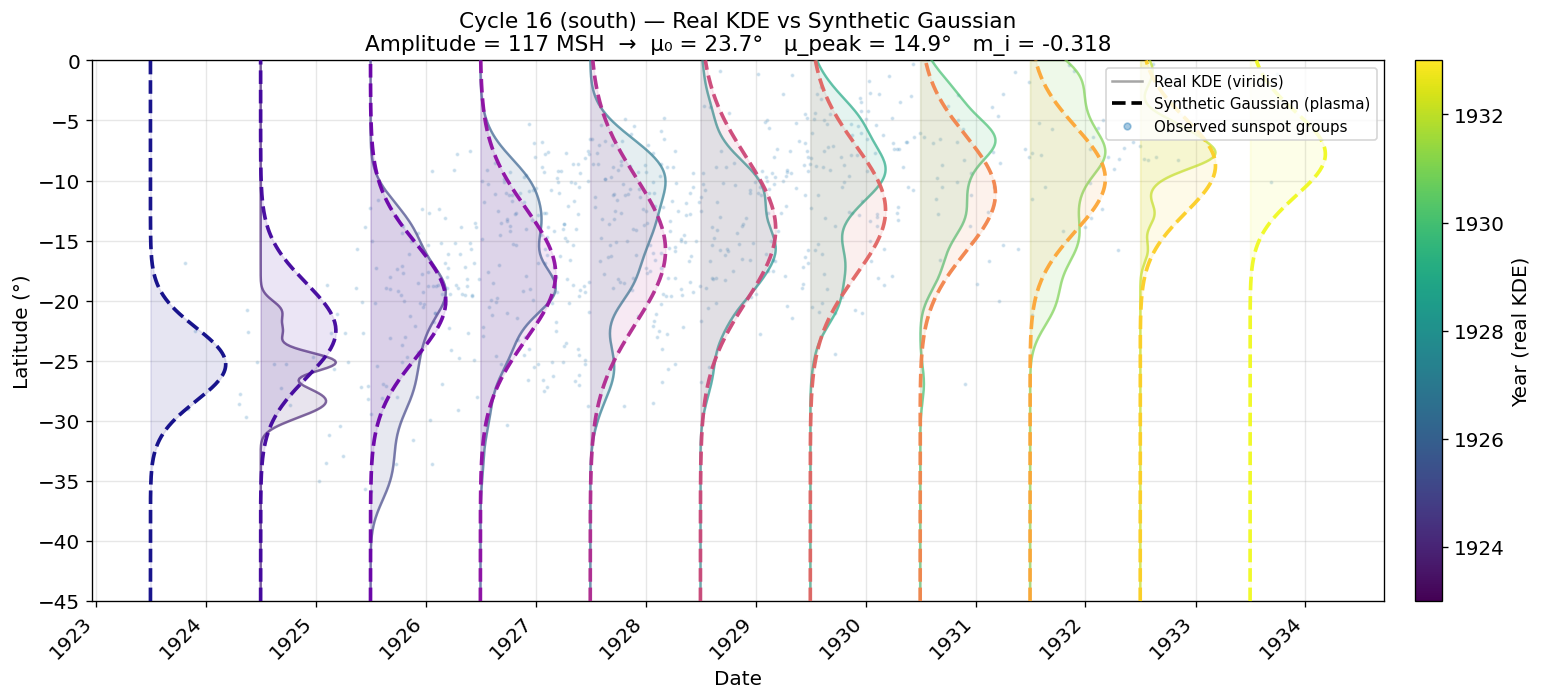

In [41]:
# Task 20: Putting It All Together — Synthesizing a Wing from Amplitude
# cycle_number and hemisphere are set in the cell above (default: 24 / north)

# ── Step 2: predict shape parameters from amplitude ───────────────────────
amp_20 = amp_lookup.get((cycle_number, hemisphere))
print(f"Cycle {cycle_number} ({hemisphere}): peak amplitude = {amp_20:.0f} MSH")

mu0_pred    = linear_fit(amp_20, *fit_results_19["mu0"])
mupeak_pred = linear_fit(amp_20, *fit_results_19["mu_peak"])
mi_pred     = linear_fit(amp_20, *fit_results_19["m_i"])
print(f"  Predicted μ₀     = {mu0_pred:.2f}°   (earliest significant emergence latitude)")
print(f"  Predicted μ_peak = {mupeak_pred:.2f}°   (detachment latitude)")
print(f"  Predicted m_i    = {mi_pred:.4f}    (poleward slope)")

# ── Step 3: annual mean latitudes from the universal path ─────────────────
t0_ref_20 = t0_refined[(cycle_number, hemisphere)]
df_sel_20  = df[(df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
                & df["tau_refined"].notna()]
tau_min_20 = df_sel_20["tau_refined"].min()
tau_max_20 = df_sel_20["tau_refined"].max()

# Use the same years as the KDE plot — guarantees 1:1 correspondence
year_ann = np.array(years_in_cycle)
tau_ann  = (year_ann + 0.5) - t0_ref_20
mu_ann   = exp_decay(tau_ann, a_mu_univ, b_mu_univ)
print(f"\nSynthetic years: {year_ann}  (μ range: {mu_ann.min():.1f}°–{mu_ann.max():.1f}°)")

# ── Steps 4–6: σ per year from the piecewise-linear model ────────────────
sigma_ann = np.array([
    piecewise_linear_wing(mu, m_shared_fit, b_shared_fit, mupeak_pred, mi_pred)
    for mu in mu_ann
])

# ── Step 7: overlay synthetic Gaussians on the real KDE butterfly diagram ─
sign     = +1 if hemisphere == "north" else -1
cmap_syn = plt.get_cmap("plasma", len(year_ann))

fig, ax = plt.subplots(figsize=(14, 6))

# Background scatter
sc_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=sc_color, alpha=0.15, zorder=1)

# Real KDE profiles (viridis — redrawn from the cell above)
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde_obj  = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde_obj(lat_grid)
    kde_sc   = kde_vals / kde_vals.max() * kde_width_days
    center   = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_sc]
    col_r    = cmap(i)   # viridis from the cell above
    ax.plot(x_curve, lat_grid, color=col_r, linewidth=1.5, alpha=0.65, zorder=3)
    ax.fill_betweenx(lat_grid, [center] * len(lat_grid), x_curve,
                     color=col_r, alpha=0.12, zorder=2)

# Synthetic Gaussian profiles (plasma, dashed)
for j, (yr, mu, sigma) in enumerate(zip(year_ann, mu_ann, sigma_ann)):
    if sigma <= 0:
        continue
    center_lat = sign * mu   # positive for north, negative for south
    gauss_vals = sp_norm.pdf(lat_grid, loc=center_lat, scale=sigma)
    if gauss_vals.max() == 0:
        continue
    gauss_sc = gauss_vals / gauss_vals.max() * kde_width_days
    center   = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in gauss_sc]
    col_s    = cmap_syn(j)
    ax.plot(x_curve, lat_grid, color=col_s, linewidth=2.2, linestyle="--",
            alpha=0.95, zorder=5)
    ax.fill_betweenx(lat_grid, [center] * len(lat_grid), x_curve,
                     color=col_s, alpha=0.10, zorder=4)

# Colour bar for real KDE (viridis)
sm_r = plt.cm.ScalarMappable(cmap="viridis",
    norm=plt.Normalize(vmin=years_in_cycle[0], vmax=years_in_cycle[-1]))
sm_r.set_array([])
cbar = fig.colorbar(sm_r, ax=ax, pad=0.02)
cbar.set_label("Year (real KDE)")

# Legend
leg_elements = [
    Line2D([0], [0], color="gray",  linewidth=1.5, alpha=0.7,
           label="Real KDE (viridis)"),
    Line2D([0], [0], color="black", linewidth=2.2, linestyle="--",
           label="Synthetic Gaussian (plasma)"),
    Line2D([0], [0], color=sc_color, marker="o", markersize=4,
           linestyle="None", alpha=0.4, label="Observed sunspot groups"),
]
ax.legend(handles=leg_elements, loc="upper right", fontsize=9)

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — Real KDE vs Synthetic Gaussian\n"
    f"Amplitude = {amp_20:.0f} MSH  →  μ₀ = {mu0_pred:.1f}°   "
    f"μ_peak = {mupeak_pred:.1f}°   m_i = {mi_pred:.3f}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (°)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## Setup: `compute_global_nll` — A Single Number to Rule Them All

Before the per-cycle diagnostics, run the cell below once. It does two things:

1. **Builds a compact data cache** (`cycle_data_global`) — a list of pre-computed (τ, μ, latitudes) triples for every valid year in every hemisphere-cycle. This is computed once and reused throughout Tasks 21–24, keeping DataFrame access out of any inner optimization loop.

2. **Defines `compute_global_nll(fit_results)`** — a function that takes a set of amplitude–shape coefficients and returns the **mean per-year-normalized NLL across the entire dataset**:

$$\text{Global NLL}(a_0, b_0, \ldots) = \frac{1}{N_{\text{terms}}} \sum_{\text{cycles}} \sum_{\text{years}} \left[ -\frac{1}{n_t} \sum_i \log \mathcal{N}(x_i \mid \mu_t, \sigma_t) \right]$$

This is your **scoreboard metric** for the rest of the notebook. Lower is better. The Task 19 two-stage fits give you the baseline; your job is to beat it.

```python
nll = compute_global_nll(fit_results_19)          # evaluate Task 19 baseline
nll = compute_global_nll(my_fit)                  # evaluate your model
nll = compute_global_nll(my_fit, m_sh=0.12, b_sh=-0.5)   # also optimize the equatorial line
```

In [42]:
# Setup: pre-compute cycle data cache and define the global scoreboard metric.
# Run this cell once before executing Tasks 21–24.

df19_records_global = []
cycle_data_global   = []
for rec in df19.to_dict("records"):
    cyc, hemi = rec["cycle"], rec["hemisphere"]
    A = amp_lookup.get((int(cyc), hemi))
    if A is None:
        continue
    df_ch = df[(df["CYCLE"] == cyc) & (df["hemisphere"] == hemi)]
    years_data = []
    for yr in sorted(df_ch["year"].unique()):
        tau  = (yr + 0.5) - t0_refined[(int(cyc), hemi)]
        mu   = exp_decay(tau, a_mu_univ, b_mu_univ)
        lats = df_ch.loc[df_ch["year"] == yr, "latitude"].abs().values
        if len(lats) >= 5:
            years_data.append((tau, mu, lats))
    if years_data:
        df19_records_global.append(rec)
        cycle_data_global.append((A, years_data))


def compute_global_nll(fit_results, m_sh=None, b_sh=None):
    """
    Mean per-year-normalized NLL across all hemisphere-cycles — the scoreboard metric.

    Parameters
    ----------
    fit_results : dict with keys 'mu0', 'mu_peak', 'm_i'
        Each value is a (slope, intercept) tuple: param(A) = slope * A + intercept.
        Same format as fit_results_19 from Task 19.
    m_sh, b_sh : float, optional
        Override the universal equatorial line parameters.
        Defaults to m_shared_fit / b_shared_fit from Section 5.

    Returns
    -------
    float — lower is better.  Units: nats/year.
    """
    if m_sh is None: m_sh = m_shared_fit
    if b_sh is None: b_sh = b_shared_fit
    a_mu0,    b_mu0    = fit_results["mu0"]
    a_mupeak, b_mupeak = fit_results["mu_peak"]
    a_mi,     b_mi     = fit_results["m_i"]
    total, n_terms = 0.0, 0
    for A, years_data in cycle_data_global:
        mu0_p    = a_mu0 * A + b_mu0
        mupeak_p = a_mupeak * A + b_mupeak
        mi_p     = a_mi * A + b_mi
        for tau, mu, lats in years_data:
            if mu > mu0_p:
                continue
            sigma = piecewise_linear_wing(mu, m_sh, b_sh, mupeak_p, mi_p)
            if sigma <= 0:
                continue
            total -= sp_norm.logpdf(lats, loc=mu, scale=sigma).mean()
            n_terms += 1
    return total / max(n_terms, 1)


nll_baseline = compute_global_nll(fit_results_19)
n_cycles = len(cycle_data_global)
n_terms  = sum(len(yd) for _, yd in cycle_data_global)
print(f"Dataset: {n_cycles} hemisphere-cycles  |  {n_terms} valid year-cycle terms")
print(f"\nBaseline NLL (Task 19 two-stage fits): {nll_baseline:.5f} nats/year")
print("Beat this number in Tasks 23–24 and in the 'Going Further' experiments.")

Dataset: 24 hemisphere-cycles  |  249 valid year-cycle terms

Baseline NLL (Task 19 two-stage fits): 3.07909 nats/year
Beat this number in Tasks 23–24 and in the 'Going Further' experiments.


---
# Week 07 Tasks: Building the Diffusion Forward Pass

Everything above this line is **recap and setup** — the classical statistical
model from Weeks 03–06, the per-cycle shape fits, and the global scoreboard
metric. Below this line begins the Week 07 work proper: turn the classical
model into a dataset of residuals, define the splits, and implement the
forward diffusion process in pure numpy.

The tasks build sequentially. Tasks 26–27 prepare the data; Tasks 28–29
implement the forward process; Tasks 30–32 verify it behaves the way the
mathematics says it should.


---
## Task 26 — Build the per-window dataset table

The training data for the diffusion model is a table where each row is one
**6-month window** of one hemispheric cycle, and the most important columns
are the empirical and parametric latitude histograms for that window. The
**residual** for the window is then *empirical histogram − parametric
histogram*, both expressed as densities on the same latitude grid.

Two design choices to flag explicitly before you start, because they affect
every downstream task:

- **Non-overlapping 6-month windows.** Each calendar half-year contributes one
  row. An alternative would be sliding 6-month windows that step by, say,
  one month — that gives more rows but they are not statistically
  independent. We choose non-overlapping windows so that "row count" and
  "independent observation count" are the same number.
- **15 latitude bins of 3° width covering 0°–45°.** The Spörer zone is
  bounded between roughly 5° and 40°, so bins 0 (0°–3°) and 14 (42°–45°)
  will be near-empty for most cycles. We keep them anyway: the residual at
  those bins is small *by construction*, and the diffusion model will learn
  this trivial structure quickly. Trimming the grid would create a special
  case that is more confusing than useful.

**Tasks:**
- For every (cycle, hemisphere) with `cycle ≥ 12`, identify the calendar
  span of the cycle and partition it into consecutive non-overlapping
  6-month windows. Discard any window with fewer than 20 observed sunspot
  group emergences (too few to form a meaningful histogram).
- For each retained window, compute and store as columns:
  - `cycle`, `hemisphere`.
  - `amplitude` — the **hemispheric cycle peak amplitude** from the
    Task 18 lookup. This is a **cycle-level constant**: every window of the
    same hemispheric cycle gets the same amplitude.
  - `tau_center` — the value of τ_refined at the centre of the 6-month window.
  - `mu_universal` — the universal-path mean latitude at `tau_center`,
    computed from `exp_decay(tau_center, a_mu_univ, b_mu_univ)`.
  - `area_smoothed` — the 12-month-smoothed total hemispheric area at the
    window centre, sampled from `smooth_north` / `smooth_south`.
  - 15 columns `hist_emp_00` … `hist_emp_14` — the **empirical density**
    of `abs_latitude` on the bin grid `np.linspace(0, 45, 16)`. Use
    `np.histogram(..., density=True)`.
  - 15 columns `hist_par_00` … `hist_par_14` — the **parametric density**
    on the same bin grid, computed by **integrating the per-window Gaussian
    over each bin** (`scipy.stats.norm.cdf` at the bin edges, then divide by
    bin width to convert to density). The Gaussian's parameters
    (μ_t, σ_t) come from the per-cycle shape fit in `results_pl`:
    μ_t = `exp_decay(tau_center, a_mu_univ, b_mu_univ)` and σ_t from
    `piecewise_linear_wing(μ_t, m_shared_fit, b_shared_fit, μ_peak_cycle, m_i_cycle)`.

**Important:** evaluating the Gaussian at bin centers is *not* the same as
integrating it over each bin. For 3° bins and σ in the 3°–7° range, the
two differ by a few percent. Integration is the principled choice and is
what we use here, so the residual is a clean difference of two density
objects.

- **Sanity plot:** pick one row of the table at random and overplot the
  empirical histogram and the parametric histogram on the same axes (bar
  chart for empirical, line plot or bar chart for parametric). They should
  resemble each other but not be identical — the difference between them
  is exactly what the diffusion model will learn to generate.


In [47]:
import numpy as np
import pandas as pd
from scipy.stats import norm as sp_norm

WINDOW_LENGTH_MONTHS = 6
MIN_OBS_PER_WINDOW = 20
LAT_BINS = np.linspace(0, 45, 16)
BIN_WIDTH = LAT_BINS[1] - LAT_BINS[0]

# Create a lookup for mu_peak and m_i from results_pl (from Section 5)
pl_params_lookup = {}
for r in results_pl:
    pl_params_lookup[(r["cycle"], r["hemisphere"])] = {
        "mu_peak": r["mu_peak"],
        "m_i": r["m_i"]
    }

window_records = []

for hc_result in results_pl: # Iterate through hemisphere-cycles that have piecewise linear fits
    cyc = hc_result["cycle"]
    hemi = hc_result["hemisphere"]

    # Get cycle-specific amplitude from Task 18 lookup
    amplitude = amp_lookup.get((cyc, hemi))
    if amplitude is None or np.isnan(amplitude):
        continue

    # Get cycle-specific refined t0
    t0_ref = t0_refined.get((cyc, hemi))
    if t0_ref is None:
        continue

    # Get per-cycle mu_peak and m_i for piecewise_linear_wing
    pl_params = pl_params_lookup.get((cyc, hemi))
    if pl_params is None:
        continue
    mu_peak_cycle = pl_params["mu_peak"]
    m_i_cycle = pl_params["m_i"]

    # Filter main DataFrame for the current hemisphere-cycle
    df_ch = df[(df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["date"].notna()].copy()
    if df_ch.empty:
        continue

    # Determine the time span for this cycle's windows
    start_date = df_ch["date"].min()
    end_date = df_ch["date"].max()

    # Select the appropriate smoothed area series
    smoothed_area_series = smooth_north if hemi == "north" else smooth_south

    # Generate non-overlapping 6-month windows
    current_window_start = start_date
    while current_window_start <= end_date:
        current_window_end = current_window_start + pd.DateOffset(months=WINDOW_LENGTH_MONTHS) - pd.Timedelta(days=1)
        if current_window_end > end_date:
            current_window_end = end_date # Adjust last window to not exceed end_date

        # Ensure the window has a valid range
        if current_window_start > current_window_end:
            break

        df_window = df_ch[(df_ch["date"] >= current_window_start) & (df_ch["date"] <= current_window_end)]

        if len(df_window) >= MIN_OBS_PER_WINDOW:
            # Calculate window center date and decimal year
            window_center_date = current_window_start + pd.DateOffset(months=WINDOW_LENGTH_MONTHS // 2)
            decimal_year_center = window_center_date.year + window_center_date.dayofyear / 365.25

            # tau_center
            tau_center = decimal_year_center - t0_ref

            # mu_universal
            mu_universal = exp_decay(tau_center, a_mu_univ, b_mu_univ)

            # area_smoothed (interpolate for the exact window_center_date)
            area_smoothed = smoothed_area_series.reindex(smoothed_area_series.index.union([window_center_date])).interpolate(method='time').loc[window_center_date]

            # Empirical histogram
            hist_emp, _ = np.histogram(df_window["abs_latitude"], bins=LAT_BINS, density=True)

            # Parametric histogram
            mu_t = mu_universal
            sigma_t = piecewise_linear_wing(mu_t, m_shared_fit, b_shared_fit, mu_peak_cycle, m_i_cycle)

            hist_par = np.zeros(len(LAT_BINS) - 1)
            if sigma_t > 0:
                cdf_at_edges = sp_norm.cdf(LAT_BINS, loc=mu_t, scale=sigma_t)
                hist_par = (cdf_at_edges[1:] - cdf_at_edges[:-1]) / BIN_WIDTH

            record = {
                "cycle": cyc,
                "hemisphere": hemi,
                "amplitude": amplitude,
                "tau_center": tau_center,
                "mu_universal": mu_universal,
                "area_smoothed": area_smoothed
            }
            for i in range(len(hist_emp)):
                record[f"hist_emp_{i:02d}"] = hist_emp[i]
                record[f"hist_par_{i:02d}"] = hist_par[i]
            window_records.append(record)

        current_window_start += pd.DateOffset(months=WINDOW_LENGTH_MONTHS)

df_windows = pd.DataFrame(window_records)
print(f"Created dataframe with {len(df_windows)} window records.")
display(df_windows.head())

Created dataframe with 349 window records.


,cycle,hemisphere,amplitude,tau_center,mu_universal,area_smoothed,hist_emp_00,hist_par_00,hist_emp_01,hist_par_01,...,hist_emp_10,hist_par_10,hist_emp_11,hist_par_11,hist_emp_12,hist_par_12,hist_emp_13,hist_par_13,hist_emp_14,hist_par_14
0,12.0,south,148.840101,-1.432008,19.343865,43.267663,0.000000,0.000416,0.000000,0.002033,...,0.022989,0.006576,0.0,0.001747,0.0,0.000347,0.0,0.000051,0.0,5.681761e-06
1,12.0,south,148.840101,-0.936457,18.247384,39.318499,0.000000,0.000848,0.009804,0.003593,...,0.009804,0.004436,0.0,0.001097,0.0,0.000204,0.0,0.000029,0.0,3.002487e-06
2,12.0,south,148.840101,-0.432008,17.195030,61.806792,0.007752,0.001571,0.007752,0.005843,...,0.000000,0.002989,0.0,0.000693,0.0,0.000122,0.0,0.000016,0.0,1.621863e-06
3,12.0,south,148.840101,0.063543,16.220353,78.802153,0.000000,0.002636,0.034483,0.008725,...,0.000000,0.002046,0.0,0.000448,0.0,0.000075,0.0,0.000009,0.0,9.144664e-07
4,12.0,south,148.840101,0.567992,15.284901,80.197718,0.000000,0.004134,0.006173,0.012293,...,0.000000,0.001407,0.0,0.000292,0.0,0.000046,0.0,0.000006,0.0,5.266805e-07


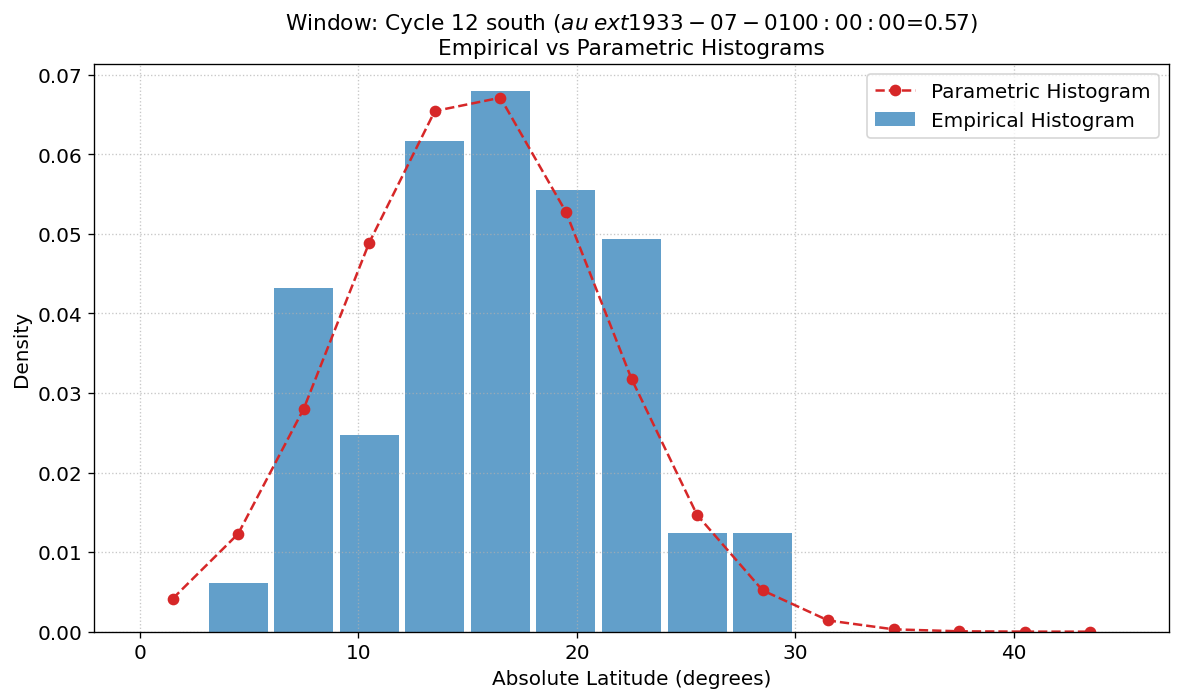

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Sanity plot: Pick one row at random
random_row_idx = 4 # Changed to specify row 4
random_window = df_windows.iloc[random_row_idx]

# Extract histograms
hist_emp_cols = [f"hist_emp_{i:02d}" for i in range(15)]
hist_par_cols = [f"hist_par_{i:02d}" for i in range(15)]

emp_hist = random_window[hist_emp_cols].values
par_hist = random_window[hist_par_cols].values

# Bin centers for plotting
bin_centers = (LAT_BINS[:-1] + LAT_BINS[1:]) / 2

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(bin_centers, emp_hist, width=BIN_WIDTH * 0.9, alpha=0.7, label="Empirical Histogram", color="tab:blue")
ax.plot(bin_centers, par_hist, color="tab:red", linestyle='--', marker='o', label="Parametric Histogram")

ax.set_xlabel("Absolute Latitude (degrees)")
ax.set_ylabel("Density")
ax.set_title(f"Window: Cycle {int(random_window['cycle'])} {random_window['hemisphere']} ($\tau_\text{center}$={random_window['tau_center']:.2f})\nEmpirical vs Parametric Histograms")
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

---
## Task 27 — Stratified train / validation / test split

Diffusion training, like supervised training, needs three disjoint splits.
The roles, however, are slightly different from what you may be used to:

- **Training set:** what the model sees during gradient updates.
- **Validation set:** used for **early stopping** (decide when to halt
  training) and for **schedule / hyperparameter selection** (compare
  candidate noise schedules, network widths, weighting schemes). Touched
  many times during model development, but never used in gradient updates.
- **Test set:** touched only when reporting the final model's performance.
  If you tune anything against the test set, your reported numbers are
  optimistic and will not reproduce.

The split is by **hemispheric cycle**, not by row. Two different windows
of the same hemispheric cycle are not independent observations: they share
the same amplitude, the same per-cycle shape parameters, and overlapping
physics. Splitting by row would leak information from train to validation
and inflate your scores.

We further want the split to be **stratified by cycle amplitude** so that
all three sets contain a representative mix of strong and weak cycles. A
random split could land all the weakest cycles in the test set and produce
a useless evaluation.

**Tasks:**
- Build a table with one row per hemispheric cycle, columns
  `(cycle, hemisphere, amplitude)`, where `amplitude` is the same Task 18
  peak amplitude used in Task 26.
- Sort the table by amplitude, **strongest first**.
- Walk down the sorted list and assign every fifth cycle (starting from
  index 0) to the **test set** — this is uniform sampling along the
  amplitude axis, which is what stratification means in this context.
- From the remaining cycles, walk down the sorted list and assign every
  fifth cycle (starting from index 0 of the remainder) to the
  **validation set**.
- Everything left is the **training set**.
- **Sanity plot:** plot a histogram (or empirical CDF) of cycle amplitudes
  for each of the three sets on the same axes. The three distributions
  should look similar — same range, same overall shape. If one set is
  systematically biased toward strong or weak cycles, the stratification
  has gone wrong.

**Ramification:** with ~46 hemispheric cycles total, a 60/20/20 split
yields roughly 28 training, 9 validation, 9 test cycles. This is decisively
small-data territory. Cross-validation across the train/validation
boundary would give more statistically robust hyperparameter choices, and
is a natural Week 09 extension once the basic pipeline works.


In [48]:
from sklearn.model_selection import train_test_split

# 1. Build a table with one row per hemispheric cycle (cycle, hemisphere, amplitude)
# We can use the pl_params_lookup created in Task 26 to get unique (cycle, hemisphere) pairs
# and then retrieve their amplitudes from amp_lookup.

cycle_amplitudes = []
for (cyc, hemi), params in pl_params_lookup.items():
    amplitude = amp_lookup.get((cyc, hemi))
    if amplitude is not None and not np.isnan(amplitude):
        cycle_amplitudes.append({"cycle": cyc, "hemisphere": hemi, "amplitude": amplitude})

df_cycle_amplitudes = pd.DataFrame(cycle_amplitudes)

# 2. Sort the table by amplitude, strongest first
df_cycle_amplitudes = df_cycle_amplitudes.sort_values(by="amplitude", ascending=False).reset_index(drop=True)

# Prepare lists to store cycle identifiers for each split
train_cycles = []
val_cycles = []
test_cycles = []

# 3. Walk down the sorted list and assign every fifth cycle to the test set
# From the remaining cycles, every fifth cycle to the validation set.
# Everything left is the training set.

remaining_cycles_for_val_and_train = []
for i, row in df_cycle_amplitudes.iterrows():
    if (i % 5) == 0:
        test_cycles.append((row["cycle"], row["hemisphere"]))
    else:
        remaining_cycles_for_val_and_train.append((row["cycle"], row["hemisphere"]))

# Convert remaining_cycles_for_val_and_train to a DataFrame for easier processing for validation split
# Re-sort to maintain the amplitude stratification for the next step
df_remaining_cycles = df_cycle_amplitudes[df_cycle_amplitudes.apply(lambda x: (x['cycle'], x['hemisphere']) in remaining_cycles_for_val_and_train, axis=1)].reset_index(drop=True)

for i, row in df_remaining_cycles.iterrows():
    if (i % 5) == 0: # Every fifth from remaining for validation
        val_cycles.append((row["cycle"], row["hemisphere"]))
    else:
        train_cycles.append((row["cycle"], row["hemisphere"]))

# Convert to sets for faster lookup if needed later, or keep as lists
train_cycles_set = set(train_cycles)
val_cycles_set = set(val_cycles)
test_cycles_set = set(test_cycles)

print(f"Total hemispheric cycles: {len(df_cycle_amplitudes)}")
print(f"Training cycles: {len(train_cycles)}")
print(f"Validation cycles: {len(val_cycles)}")
print(f"Test cycles: {len(test_cycles)}")

# Filter df_windows to create train/val/test dataframes
df_train = df_windows[df_windows.apply(lambda x: (x['cycle'], x['hemisphere']) in train_cycles_set, axis=1)]
df_val = df_windows[df_windows.apply(lambda x: (x['cycle'], x['hemisphere']) in val_cycles_set, axis=1)]
df_test = df_windows[df_windows.apply(lambda x: (x['cycle'], x['hemisphere']) in test_cycles_set, axis=1)]

print(f"\nTrain records: {len(df_train)}")
print(f"Validation records: {len(df_val)}")
print(f"Test records: {len(df_test)}")

Total hemispheric cycles: 24
Training cycles: 15
Validation cycles: 4
Test cycles: 5

Train records: 216
Validation records: 57
Test records: 76


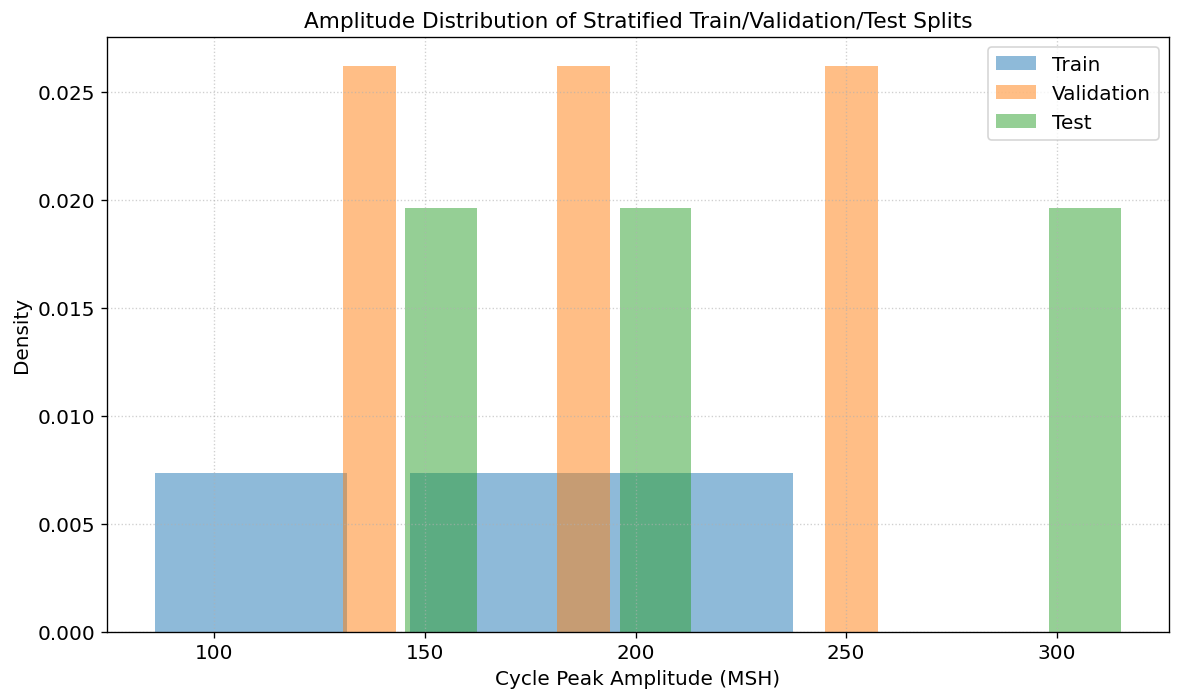

In [29]:
# Sanity plot: plot a histogram (or empirical CDF) of cycle amplitudes for each split

plt.figure(figsize=(10, 6))

amp_train = df_cycle_amplitudes[df_cycle_amplitudes.apply(lambda x: (x['cycle'], x['hemisphere']) in train_cycles_set, axis=1)]['amplitude']
amp_val = df_cycle_amplitudes[df_cycle_amplitudes.apply(lambda x: (x['cycle'], x['hemisphere']) in val_cycles_set, axis=1)]['amplitude']
amp_test = df_cycle_amplitudes[df_cycle_amplitudes.apply(lambda x: (x['cycle'], x['hemisphere']) in test_cycles_set, axis=1)]['amplitude']

plt.hist(amp_train, bins=10, alpha=0.5, label='Train', density=True)
plt.hist(amp_val, bins=10, alpha=0.5, label='Validation', density=True)
plt.hist(amp_test, bins=10, alpha=0.5, label='Test', density=True)

plt.title('Amplitude Distribution of Stratified Train/Validation/Test Splits')
plt.xlabel('Cycle Peak Amplitude (MSH)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

---
## Task 28 — Define the cosine noise schedule

The forward process corrupts a clean residual r into a noisy version r_t at
**timestep** t ∈ {0, 1, …, T} according to

$$r_t \;=\; \alpha_t \cdot r \;+\; \sigma_t \cdot \varepsilon, \qquad
\varepsilon \sim \mathcal{N}(0, I).$$

The pair (α_t, σ_t) is the **noise schedule**. It is fixed before training
begins, computed once, stored as two arrays of length T+1, and looked up by
index thereafter.

We use the **cosine schedule** of Nichol & Dhariwal (2021), which is
**variance-preserving**: α_t² + σ_t² = 1 at every t, so the total variance
of r_t stays bounded as t increases. This contrasts with the
**variance-exploding** family (used in some image-generation papers) where
σ_t grows without bound while α_t = 1 throughout. For low-dimensional data
like ours, variance-preserving is more stable and easier to train.

The cosine schedule defines a smooth function

$$\bar{\alpha}_t \;=\; \frac{\cos\!\big(\tfrac{\pi}{2} \cdot \tfrac{t/T + s}{1 + s}\big)^2}{\cos\!\big(\tfrac{\pi}{2} \cdot \tfrac{s}{1 + s}\big)^2}$$

with a small offset `s ≈ 0.008`, and then

$$\alpha_t = \sqrt{\bar{\alpha}_t}, \qquad \sigma_t = \sqrt{1 - \bar{\alpha}_t}.$$

The **signal-to-noise ratio** at timestep t is

$$\mathrm{SNR}(t) \;=\; \frac{\alpha_t^2}{\sigma_t^2} \;=\; \frac{\bar{\alpha}_t}{1 - \bar{\alpha}_t}.$$

It starts very large at t = 0 (almost pure signal), passes through 1 at the
schedule's halfway point, and falls toward 0 at t = T (almost pure noise).
The **shape of the SNR descent** is what the schedule actually controls;
α_t and σ_t are bookkeeping derived from it.

**Tasks:**
- Set `T = 200`. Implement the cosine schedule above with offset
  `s = 0.008`. Compute `alpha_bar` (length T+1), `alpha` (length T+1), and
  `sigma` (length T+1) as numpy arrays.
- For numerical stability, **clip** the per-step noise variance — define
  `beta_t = 1 - alpha_bar[t] / alpha_bar[t-1]` and clip `beta_t` to
  `[1e-8, 0.999]`. Recompute `alpha_bar` from the clipped `beta` if
  needed; this prevents pathological behaviour at the extreme timesteps.
- Plot α_t, σ_t, and SNR(t) on the same figure (use a log y-axis for SNR).
  Mark the timestep at which SNR(t) = 1 with a vertical line.
- **Reading the plot:** identify the timesteps where (i) the signal is
  almost untouched (high SNR), (ii) the signal is roughly half-corrupted
  (SNR ≈ 1), (iii) the signal is essentially gone (low SNR). These three
  regimes correspond to the three regimes the diffusion model has to
  handle next week.


/tmp/ipykernel_1567/3485193502.py:27: RuntimeWarning: divide by zero encountered in divide
  snr = alpha_bar / (1 - alpha_bar)


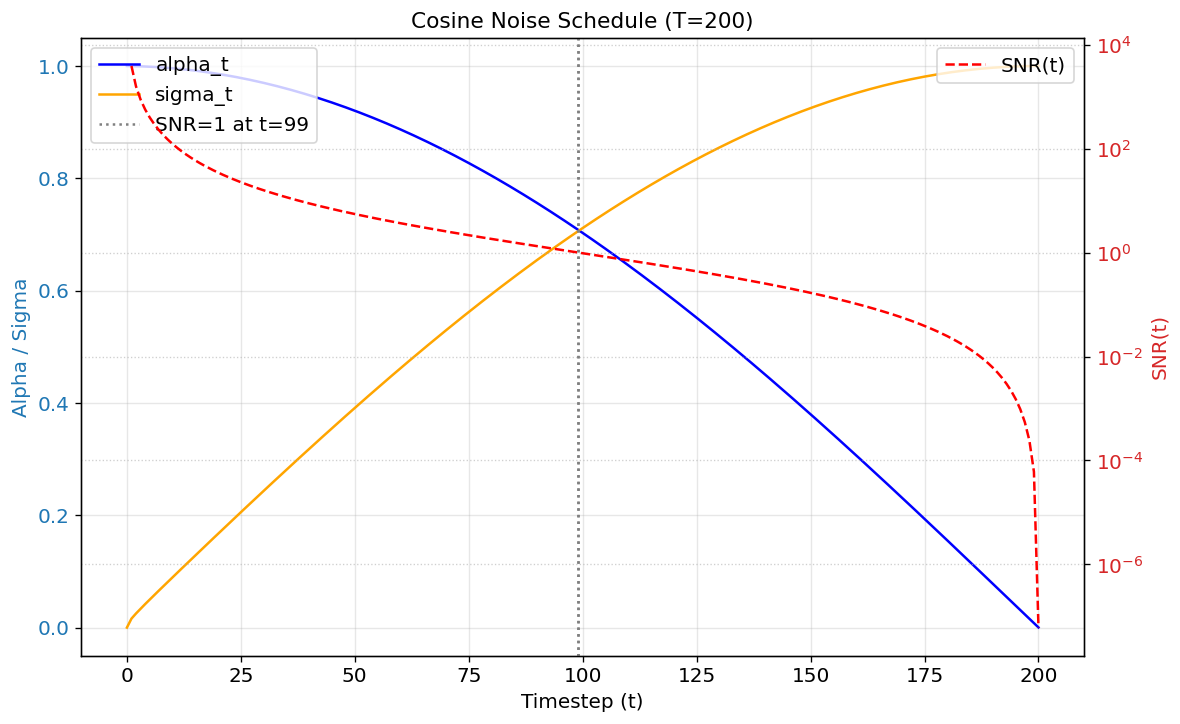

In [50]:
# Task 28: Define the cosine noise schedule

T = 200
s = 0.008 # offset

t_steps = np.arange(0, T + 1)

# Calculate alpha_bar
alpha_bar = (np.cos((t_steps/T + s) / (1 + s) * np.pi / 2)) ** 2

# Clip beta_t for numerical stability
beta_t = 1 - (alpha_bar[1:] / alpha_bar[:-1])
beta_t = np.clip(beta_t, 1e-8, 0.999)

# Recalculate alpha_bar from clipped beta_t
alpha_bar_clipped = np.zeros(T + 1)
alpha_bar_clipped[0] = 1 # alpha_bar_0 is always 1 (no noise)
for t in range(1, T + 1):
    alpha_bar_clipped[t] = alpha_bar_clipped[t-1] * (1 - beta_t[t-1])
alpha_bar = alpha_bar_clipped

# Calculate alpha and sigma
alpha = np.sqrt(alpha_bar)
sigma = np.sqrt(1 - alpha_bar)

# Calculate SNR
snr = alpha_bar / (1 - alpha_bar)

# Plot alpha_t, sigma_t, and SNR(t)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Timestep (t)')
ax1.set_ylabel('Alpha / Sigma', color=color)
ax1.plot(t_steps, alpha, label='alpha_t', color='blue')
ax1.plot(t_steps, sigma, label='sigma_t', color='orange')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('SNR(t)', color=color)
ax2.plot(t_steps, snr, label='SNR(t)', color='red', linestyle='--')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

# Mark timestep where SNR(t) = 1
snr_one_idx = np.argmin(np.abs(snr - 1))
ax1.axvline(x=t_steps[snr_one_idx], color='gray', linestyle=':', label=f'SNR=1 at t={t_steps[snr_one_idx]}')
ax2.axvline(x=t_steps[snr_one_idx], color='gray', linestyle=':')

fig.tight_layout()
plt.title('Cosine Noise Schedule (T=200)')
plt.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

The figure shows the SNR is high when alpha_t is highest and the sigma_t is lowest. The gray lines indicates where the signal is about half corrupted. The signel is essentially gone when the alpha_t is the lowest and the sigma_t is the highest. You can follow this trend by looking at the red dotted line showing the SNR trend over time.

---
## Task 29 — Forward corruption: from clean residual to noise level t in one step

The forward process is mathematically a **Markov chain** of T small noising
steps from t to t+1, but the closed-form expression r_t = α_t·r + σ_t·ε
lets you jump from t = 0 to *any* t in a single call. This is what makes
training tractable: at each gradient step you sample a random t, corrupt
the clean residual to that t directly, and ask the network to undo it. You
never simulate the chain.

**Tasks:**
- Implement a function `forward_corrupt(r, t, alpha, sigma, rng=None)`
  that takes a clean residual `r` of shape `(15,)`, an integer timestep
  `t`, the schedule arrays from Task 28, and an optional `numpy.random.Generator`
  for reproducibility, and returns:
  - `r_t` — the noisy residual, shape `(15,)`.
  - `eps` — the noise sample that was added, shape `(15,)`.
  Returning both is important for next week: the training objective will
  ask the network to predict `eps` from `r_t`, so we need both during
  training data generation.
- Add a vectorised variant `forward_corrupt_batch(R, t_array, alpha, sigma, rng=None)`
  that takes `R` of shape `(N, 15)` and `t_array` of shape `(N,)` (a
  *different* timestep for each row) and returns `(R_t, EPS)` of the same
  shape. This is the version next week's training loop will call.
- **Sanity check:** apply `forward_corrupt(r, 0, ...)` to a real residual.
  The output `r_t` should equal `r` to floating-point precision and `eps`
  can be anything (it will be multiplied by σ_0 ≈ 0). Apply
  `forward_corrupt(r, T, ...)`: the output should be dominated by `eps`
  and bear no obvious resemblance to `r`.


In [21]:
# Put your code here for Task 29.


---
## Task 30 — Visualize the forward trajectory

This is the headline visualization of the week. A picture of one residual
being progressively destroyed by the forward process is the conceptual
anchor for everything in Weeks 08 and 09. If a colleague who has never
seen diffusion asks you to explain what it is, this is the figure you
will show them.

**Tasks:**
- Pick one specific row from your training table that has a visually
  interesting residual — ideally one where the empirical histogram shows
  **bimodality** or asymmetric tails that the parametric Gaussian misses.
  Print its `(cycle, hemisphere, tau_center)` so the choice is reproducible.
- Apply `forward_corrupt` at six representative timesteps:
  `t ∈ {0, T/8, T/4, T/2, 3T/4, T}`. Use the *same* random seed for all
  six so the trajectory is deterministic and the comparison is fair —
  what changes between subplots is only the noise level, not the noise
  realization.
- Plot all six on a 2 × 3 grid of subplots. Each subplot shows:
  - the noisy residual r_t as a bar chart on the 15-bin latitude grid;
  - the SNR(t) value in the title.
  Use the same y-axis limits across all subplots so the eye can track the
  growing variance.
- Underneath, plot the **same six trajectories with a different random
  seed** and observe that at high SNR (low t) the trajectories agree
  closely, while at low SNR (high t) they diverge — different noise
  realizations produce visibly different r_t, even from the same r and t.
  This previews the intrinsic stochasticity of the forward process that
  Task 32 examines quantitatively.


In [22]:
# Put your code here for Task 30.


---
## Task 31 — Verify the limiting behaviour at t = T

A property of variance-preserving schedules is that as t → T, the
distribution of r_t converges to the standard Gaussian N(0, I) — and
crucially, this limit is **independent of the original data**. The
distribution at t = T does not "remember" what residuals you started from.
This is why next week's reverse process can begin from a fresh draw of
N(0, I) without any learning at the first step: at t = T, *all* clean
residuals corrupt to the same distribution, so we can sample that
distribution analytically rather than learning it.

This task asks you to verify the limiting behaviour empirically.

**Tasks:**
- Take the full **training set** of clean residuals (one residual per
  6-month window in the training cycles). Apply `forward_corrupt_batch`
  with `t_array = T` for every row — i.e., corrupt every training
  residual all the way to t = T, each with an independent fresh ε draw.
- For the resulting set of noised residuals at t = T:
  - Compute the **bin-wise mean** across all rows (a vector of length 15).
    Plot it as a bar chart. It should be statistically indistinguishable
    from zero, with bin-wise standard error roughly 1/√N where N is the
    number of training rows.
  - Compute the **bin-wise standard deviation** across all rows. Plot it
    as a bar chart. It should be statistically indistinguishable from 1,
    in every bin.
  - Compute the **bin-bin covariance matrix** (shape 15 × 15) and display
    it as a heatmap. It should look like the identity matrix to plotting
    precision: ~1 on the diagonal, ~0 off-diagonal.
- **Counter-test:** repeat the same three diagnostics on the *clean*
  training residuals (i.e., t = 0). The mean is non-zero in some bins,
  the standard deviation is bin-dependent, and the covariance matrix has
  off-diagonal structure. The contrast between the t = 0 and t = T
  diagnostics is exactly the structure the diffusion model has to learn
  to generate, run in reverse.


In [23]:
# Put your code here for Task 31.


---
## Task 32 — The forward process is stochastic: many r_t's per (r, t)

A subtle point that often confuses students on first contact with
diffusion: the forward process is *not* a deterministic function of (r, t).
The same clean residual r corrupted at the same noise level t can produce
many different noisy residuals r_t — one per draw of ε. The forward
process maps each (r, t) to a **distribution** over r_t, not a single r_t.

This is why the reverse process must be a *learned* model rather than
a closed-form inverse: there is no inverse function, because the forward
process is many-to-one (in fact, many-to-many). The reverse model has to
estimate, for each noisy r_t, the most likely direction back toward the
clean data manifold — and "most likely" is a statement about a
distribution, which is what a neural network is good at approximating.

**Tasks:**
- Pick the same row you used in Task 30. Pick one intermediate timestep,
  say `t = T // 4`. Call `forward_corrupt(r, t, ...)` **100 times**, each
  with a different random seed. Collect the 100 noisy residuals into an
  array of shape `(100, 15)`.
- Plot all 100 noisy residuals on the same axes as faint lines, with the
  *clean* residual r overlaid as a thick black line. The cloud of faint
  lines should cluster around r with bin-wise spread proportional to σ_t.
- Compute the empirical mean and standard deviation across the 100
  samples in each bin, and overlay them as error bars on the clean
  residual. Verify that:
  - the empirical bin-wise mean ≈ α_t · r (the deterministic part of the
    corruption);
  - the empirical bin-wise standard deviation ≈ σ_t (the stochastic part).
- Repeat for t = T // 2 and t = 3T // 4. Watch the cloud spread out as
  σ_t grows and the deterministic centerline α_t·r shrinks toward zero.

This is the cleanest illustration of the forward process's structure
α_t (deterministic) + σ_t (stochastic) that you will see all week.


In [24]:
# Put your code here for Task 32.


---
## Where Week 07 leaves us, and what Week 08 will need

By the end of Task 32 you have built every piece of diffusion-specific
machinery the model needs, in pure numpy:

- A **dataset** of residuals indexed by hemispheric cycle and 6-month
  window (Task 26).
- A **stratified train/val/test split** by cycle amplitude that respects
  the cycle-as-unit structure of the data (Task 27).
- A **cosine noise schedule** with all the bookkeeping (α, σ, SNR)
  needed by both training and sampling (Task 28).
- A **forward corruption function** that maps (r, t) → r_t in one step,
  vectorised over batches (Task 29).
- **Three independent verifications** that the forward process behaves
  the way the mathematics says it should (Tasks 30–32).

What you have **not** built is anything with learnable parameters. There
is no neural network in this notebook; there is no PyTorch in this
notebook; there is no training loop in this notebook. That is by design.
The forward process is where all the diffusion-specific math lives, and
you have implemented it transparently and verified it works.

Next week we will build the **reverse process**: a small denoising MLP,
trained in PyTorch + Lightning, whose job is to estimate ε from r_t. The
forward apparatus you built this week will be reused unchanged — it
generates the (r_t, t, ε) training triples the network learns from.
Nothing about Task 28's schedule, Task 29's forward function, or
Task 27's splits will change in Week 08. We are simply adding the
*learned* half of the model on top of the *numerical* half you have just
built.
